# Requirements & Auxiliary Functions & Settings

## Requirements & Imports

### Requirements

#### Python Packages

In [44]:
# Instala as dependencias Python usadas no notebook
%pip install -U numpy pandas matplotlib scipy scikit-learn statsmodels rpy2 openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\gsilv\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


#### R Packages

In [45]:
# Habilita o uso das mÃ¡gicas %R e %%R para rodar cÃ³digo R diretamente em cÃ©lulas do notebook.
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [46]:
import subprocess

r_cmd = (
    'lib <- Sys.getenv("R_LIBS_USER"); '
    'dir.create(lib, recursive = TRUE, showWarnings = FALSE); '
    'install.packages("inaparc", repos = "https://cloud.r-project.org/", lib = lib)'
)

subprocess.run(["Rscript", "-e", r_cmd], check=True)

CompletedProcess(args=['Rscript', '-e', 'lib <- Sys.getenv("R_LIBS_USER"); dir.create(lib, recursive = TRUE, showWarnings = FALSE); install.packages("inaparc", repos = "https://cloud.r-project.org/", lib = lib)'], returncode=0)

In [47]:
import subprocess

r_cmd = (
    'lib <- Sys.getenv("R_LIBS_USER"); '
    'dir.create(lib, recursive = TRUE, showWarnings = FALSE); '
    'install.packages("ppclust", repos = "https://cloud.r-project.org/", lib = lib)'
)

subprocess.run(["Rscript", "-e", r_cmd], check=True)

CompletedProcess(args=['Rscript', '-e', 'lib <- Sys.getenv("R_LIBS_USER"); dir.create(lib, recursive = TRUE, showWarnings = FALSE); install.packages("ppclust", repos = "https://cloud.r-project.org/", lib = lib)'], returncode=0)

### Imports

In [48]:
from __future__ import annotations

import json
import os
import re
import subprocess
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple, Union

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from rpy2.robjects import conversion, globalenv, pandas2ri, r
from rpy2.robjects.conversion import localconverter
from scipy.stats import jarque_bera, kurtosis, norm, skew

## Auxiliary Functions & Helpers

### Helpers

In [49]:
@dataclass(frozen=True)
class HorizonConfig:
    horizon: int
    base_input_dir: str
    base_output_dir: str


def _build_default_horizon_config() -> dict[int, HorizonConfig]:
    """
    Monta o mapa de configuraÃ§Ã£o padrÃ£o por horizonte.
    """
    return {
        1: HorizonConfig(
            horizon=1,
            base_input_dir=input_RV_t1,
            base_output_dir=predictions_output_RV_t1,
        ),
        7: HorizonConfig(
            horizon=7,
            base_input_dir=input_RV_t7,
            base_output_dir=predictions_output_RV_t7,
        ),
        30: HorizonConfig(
            horizon=30,
            base_input_dir=input_RV_t30,
            base_output_dir=predictions_output_RV_t30,
        ),
    }

In [50]:
def _build_io_paths(symbol: str, base_input_dir: str, base_output_dir: str) -> dict[str, str]:
    insample_path = os.path.join(
        base_input_dir,
        "insample",
        f"{symbol}_5m_daily_insample.xlsx",
    )
    outsample_path = os.path.join(
        base_input_dir,
        "out_of_sample",
        f"{symbol}_5m_daily_outofsample.xlsx",
    )

    symbol_out_dir = os.path.join(base_output_dir, symbol)
    os.makedirs(symbol_out_dir, exist_ok=True)

    return {
        "insample_path": insample_path,
        "outsample_path": outsample_path,
        "symbol_out_dir": symbol_out_dir,
    }

In [51]:
def _validate_required_columns(
    df: pd.DataFrame,
    required_cols: list[str],
    df_name: str,
) -> None:
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(
            f"{df_name} estÃ¡ sem as colunas obrigatÃ³rias: {missing}. "
            f"Colunas disponÃ­veis: {list(df.columns)}"
        )

In [52]:
def _load_and_prepare_base_data(
    insample_path: str,
    outsample_path: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    df_train = pd.read_excel(insample_path)
    df_test = pd.read_excel(outsample_path)

    # MantÃ©m o comportamento das funÃ§Ãµes originais:
    # tenta renomear "Data" -> "Date" caso exista.
    if "Data" in df_train.columns:
        df_train.rename(columns={"Data": "Date"}, inplace=True)
    if "Data" in df_test.columns:
        df_test.rename(columns={"Data": "Date"}, inplace=True)

    _validate_required_columns(df_train, ["target", "RV"], "df_train")
    _validate_required_columns(df_test, ["target", "RV"], "df_test")

    # Se quiser exigir Date tambÃ©m, descomente:
    # _validate_required_columns(df_train, ["Date"], "df_train")
    # _validate_required_columns(df_test, ["Date"], "df_test")

    df_train["Target"] = df_train["target"]
    df_test["Target"] = df_test["target"]

    df_train["Feature Origin"] = df_train["RV"]
    df_test["Feature Origin"] = df_test["RV"]

    return df_train, df_test


In [53]:
def _save_outputs(
    df_train: pd.DataFrame,
    df_test: pd.DataFrame,
    symbol: str,
    horizon: int,
    symbol_out_dir: str,
) -> tuple[str, str]:
    train_out_path = os.path.join(
        symbol_out_dir,
        f"{symbol}_tplus{horizon}_train_with_fuzzy.xlsx",
    )
    test_out_path = os.path.join(
        symbol_out_dir,
        f"{symbol}_tplus{horizon}_test_with_fuzzy.xlsx",
    )

    df_train.to_excel(train_out_path, index=False)
    df_test.to_excel(test_out_path, index=False)

    return train_out_path, test_out_path

### Functions for data preprocessing

In [54]:
def _normalize_dates(
    df: pd.DataFrame
) -> pd.DataFrame:

    """
      Description:
        Converte a coluna 'Date' do dataframe recebido como
        parÃ¢metro (assumindo que essa coluna existe) para datetime.

      Params:
        df (pd.DataFrame): DataFrame de entrada contendo a coluna 'Date',
          alÃ©m de 'Feature Origin' e 'Target'. Assume-se que as linhas jÃ¡
          chegam ordenadas por data.

      Return:
        df (pd.DataFrame): CÃ³pia do DataFrame original com a coluna 'Date'
          convertida para datetime (valores invÃ¡lidos viram NaT).
    """

    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

    return df

In [55]:
def _align_y_next(
    target: pd.Series
) -> pd.Series:

    """
      Description:
        Prepara o alvo para previsÃ£o one-step-ahead. Ao deslocar a sÃ©rie em -1,
        garantimos que as features calculadas em t sejam pareadas com o valor
        de Target observado em t+1 (o â€œprÃ³ximo perÃ­odoâ€). Isso evita vazamento
        de informaÃ§Ã£o e alinha corretamente X_t -> y_{t+1} no treinamento/teste.

      Params:
        target (pd.Series): SÃ©rie alvo original (Target_t) no mesmo Ã­ndice
          temporal das features.

      Return:
        (pd.Series): SÃ©rie alvo deslocada em -1 (Target_{t+1}); a Ãºltima
          posiÃ§Ã£o torna-se NaN por nÃ£o haver observaÃ§Ã£o futura correspondente.
    """

    return target.shift(-1)

In [56]:
def make_har_features(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    week_len: int = 5,
    month_len: int = 22,
    include_daily: bool = True,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    ConstrÃ³i as features HAR (Heterogeneous Autoregressive) a partir da coluna
    'Feature Origin' e gera o alvo deslocado em um passo Ã  frente:

        y(t) = Target_{t+1}

    Retorna:
        X_train, y_train, X_test, y_test
    """

    if week_len < 2:
        raise ValueError("week_len deve ser >= 2.")
    if month_len < week_len:
        raise ValueError("month_len deve ser >= week_len.")

    # 1. Normaliza datas e copia
    tr = _normalize_dates(train_df)
    te = _normalize_dates(test_df)

    # 2. Concatena treino + teste numa sÃ©rie temporal contÃ­nua
    full = pd.concat([tr, te], ignore_index=True)

    n_tr = len(tr)
    n_full = len(full)

    # 3. Extrai a sÃ©rie base de volatilidade
    fo_all = full["Feature Origin"].to_numpy(dtype=float)
    s_all = pd.Series(fo_all)

    # 4. Cria as colunas HAR sobre a sÃ©rie completa
    feats_all = []

    if include_daily:
        feats_all.append(s_all.to_numpy())

    week_col = (
        s_all.rolling(window=week_len, min_periods=week_len)
        .mean()
        .to_numpy()
    )
    feats_all.append(week_col)

    month_col = (
        s_all.rolling(window=month_len, min_periods=month_len)
        .mean()
        .to_numpy()
    )
    feats_all.append(month_col)

    X_all = np.vstack(feats_all).T

    # 5. Alvo deslocado em um passo Ã  frente
    y_all_full = _align_y_next(full["Target"])

    # 6. Linhas matematicamente vÃ¡lidas
    valid_all = (~np.isnan(X_all).any(axis=1)) & (~y_all_full.isna().to_numpy())

    # 7. Define treino/teste com base em onde cai o alvo t+1
    idx_next = np.arange(n_full) + 1
    mask_y_in_train = idx_next < n_tr
    mask_y_in_test = (idx_next >= n_tr) & (idx_next < n_full)

    valid_train = valid_all & mask_y_in_train
    valid_test = valid_all & mask_y_in_test

    # 8. Separa os conjuntos finais
    X_train = X_all[valid_train].astype(np.float64)
    y_train = y_all_full[valid_train].to_numpy(dtype=np.float64)

    X_test = X_all[valid_test].astype(np.float64)
    y_test = y_all_full[valid_test].to_numpy(dtype=np.float64)

    return X_train, y_train, X_test, y_test

### Functions for training and testing model

In [57]:
def gaussmf(
    x: Union[float, np.ndarray],
    c: float,
    s: float
) -> Union[float, np.ndarray]:

    """
        Description:
            Calcula o grau de pertinÃªncia usando uma funÃ§Ã£o de pertinÃªncia gaussiana.

        Args:
            x (float | np.ndarray): Valor(es) de entrada para calcular o grau de pertinÃªncia.
            c (float): Centro da funÃ§Ã£o gaussiana.
            s (float): Desvio padrÃ£o da funÃ§Ã£o gaussiana.

        Return:
            float | np.ndarray: Grau de pertinÃªncia calculado para o(s) valor(es) de entrada.
    """

    aux = (x - c)/s  # Calcula a distÃ¢ncia normalizada do valor ao centro
    z = np.exp(-(aux*aux)/2)  # Aplica a fÃ³rmula da funÃ§Ã£o gaussiana

    return z

In [58]:
def gaussgranules(
    x: np.ndarray,
    centers: np.ndarray,
    sigmas: np.ndarray
) -> np.ndarray:

    """
        Description:
            Calcula as ativaÃ§Ãµes de mÃºltiplas regras fuzzy usando funÃ§Ãµes gaussianas.

        Args:
            x (np.ndarray): Vetor de entrada de dimensÃ£o d.
            centers (np.ndarray): Array de formato (N, d) com os centros das N regras.
            sigmas (np.ndarray): Array de formato (N, d) com os desvios padrÃ£o das N regras.

        Return:
            np.ndarray: Array de formato (N,) contendo o grau de ativaÃ§Ã£o para cada uma das N regras.
    """

    # Um centro c = (c_{1},c_{2},...,c_{n}) e um desvio padrÃ£o s = (s_{1},s_{2},...,s_{n}) definem uma regra fuzzy (chamemos r).
    # Quando aplicamos gaussmf(x,c,s) para x = (x_{1},x_{2},...,x_{n}) obtemos o grau de pertencimento do vetor x Ã  regra r.

    N, d = centers.shape  # N Ã© o nÃºmero de regras, d Ã© a dimensÃ£o representada pelo delay
    activations = []  # Lista para armazenar as ativaÃ§Ãµes de cada regra

    for i in range(N):
        mu = 1.0  # Inicializa o grau de pertinÃªncia como 1
        for j in range(d):
            # Multiplica o grau de pertinÃªncia pela ativaÃ§Ã£o da j-Ã©sima dimensÃ£o
            mu *= gaussmf(x[j], centers[i, j], sigmas[i, j]) # Multiplica o grau de pertinÃªncia da dimensÃ£o j de x Ã  regra i
        activations.append(mu)  # Adiciona o resultado Ã  lista de ativaÃ§Ãµes

    return np.array(activations)  # Converte a lista para um array numpy

In [59]:
%%R

#' @title ClusterizaÃ§Ã£o Fuzzy com Gustafson-Kessel
#' @description
#' Executa o algoritmo de clusterizaÃ§Ã£o fuzzy Gustafsonâ€“Kessel (GK) com inicializaÃ§Ã£o por k-means++ e pertinÃªncias fuzzy aleatÃ³rias.
#' A funÃ§Ã£o tambÃ©m calcula, manualmente, as matrizes de dispersÃ£o (\eqn{\Sigma_j}) e os desvios padrÃ£o por dimensÃ£o para cada cluster.
#'
#' @param x Um data.frame ou matriz numÃ©rica com n amostras (linhas) e d variÃ¡veis (colunas).
#' @param k Um inteiro representando o nÃºmero de clusters (ou regras fuzzy).
#'
#' @return Uma lista com trÃªs elementos:
#' \describe{
#'   \item{\code{centros}}{Matriz \code{k x d} contendo os centros finais de cada cluster.}
#'   \item{\code{pertinencias}}{Matriz \code{n x k} com os graus de pertinÃªncia fuzzy das amostras aos clusters.}
#'   \item{\code{desvios}}{Lista de \code{k} matrizes \code{d x d}, cada uma representando a matriz de dispersÃ£o ponderada (\eqn{\Sigma_j}) de um cluster.}
#' }
#'
#' @details
#' A funÃ§Ã£o usa:
#' \itemize{
#'   \item \code{ppclust::gk} para a execuÃ§Ã£o do algoritmo GK;
#'   \item \code{inaparc::kmpp} para inicializaÃ§Ã£o dos centros;
#'   \item \code{inaparc::imembrand} para inicializaÃ§Ã£o da matriz de pertinÃªncia.
#' }
#' O expoente de fuzzificaÃ§Ã£o \code{m} Ã© fixado em 2. As matrizes de dispersÃ£o sÃ£o calculadas usando os pesos fuzzy elevados a \code{m}, conforme a definiÃ§Ã£o clÃ¡ssica.
#'

gk_clustering <- function(x, k) {
  # Carrega o pacote 'ppclust', que fornece implementaÃ§Ãµes de algoritmos de clusterizaÃ§Ã£o fuzzy,
  # como Fuzzy C-Means (FCM), Gustafsonâ€“Kessel (GK), entre outros.
  library(ppclust)

  # Carrega o pacote 'inaparc', que provÃª mÃ©todos de inicializaÃ§Ã£o de centros e pertinÃªncias,
  # como k-means++ (kmpp) e inicializaÃ§Ã£o fuzzy aleatÃ³ria (imembrand).
  library(inaparc)

  # Garante que k seja um escalar inteiro vÃ¡lido
  k <- as.integer(as.numeric(k[1]))

  # ----------- InicializaÃ§Ã£o dos clusters -----------

  # Semente para reprodutibilidade de resultados
  set.seed(123)

  # Inicializa os centros dos clusters com o algoritmo k-means++.
  # Retorna uma lista com vÃ¡rios componentes; o '$v' acessa a matriz dos centros inicializados (k x d).
  v <- kmpp(x, k = k)$v

  # Inicializa a matriz de pertinÃªncia fuzzy (n x k), onde cada linha soma 1.
  # Essa matriz define o grau de associaÃ§Ã£o inicial de cada amostra a cada cluster.
  u <- imembrand(nrow(x), k = k)$u

  # ----------- ExecuÃ§Ã£o do algoritmo Gustafson-Kessel -----------

  # Executa o algoritmo GK (fuzzy clustering com mÃ©tricas de covariÃ¢ncia adaptativas).
  # Argumentos principais:
  # - x: conjunto de dados
  # - centers: centros inicializados (matriz k x d)
  # - memberships: matriz de pertinÃªncia inicial (n x k)
  # - m: expoente de fuzzificaÃ§Ã£o (m > 1; m = 2 Ã© o padrÃ£o mais usado)
  # - dmetric: mÃ©trica de distÃ¢ncia ("sqeuclidean" = euclidiana ao quadrado)
  # - iter.max: nÃºmero mÃ¡ximo de iteraÃ§Ãµes
  # - con.val: critÃ©rio de convergÃªncia (parar se mudanÃ§a entre iteraÃ§Ãµes < 1e-9)
  gk.res <- gk(x, centers = v, memberships = u, m = 2,
              dmetric = "sqeuclidean", iter.max = 1000, con.val = 1e-9)

  # Exporta a matriz de centros finais (k x d) para uso posterior
  centros <- gk.res$v

  # Exporta a matriz final de pertinÃªncia fuzzy (n x k)
  pertinencias <- gk.res$u

  # ----------- CÃ¡lculo manual das matrizes de dispersÃ£o (Î£_j) e desvios padrÃ£o -----------

  # Converte os dados para uma matriz numÃ©rica (n x d), onde:
  # n = nÃºmero de amostras (linhas), d = nÃºmero de variÃ¡veis (lags ou dimensÃµes)
  X <- as.matrix(x)

  # Recupera a matriz de pertinÃªncia fuzzy (n x k), onde:
  # U[i, j] representa o grau de associaÃ§Ã£o da amostra i ao cluster j
  U <- gk.res$u

  # Recupera a matriz de centros dos clusters (k x d), onde:
  # V[j, ] contÃ©m as coordenadas do centro do cluster j
  V <- gk.res$v

  # Expoente de fuzzificaÃ§Ã£o usado tanto no algoritmo quanto neste cÃ¡lculo
  m <- 2

  # Define as dimensÃµes principais do problema
  n <- nrow(X)   # nÃºmero de amostras
  k <- ncol(U)   # nÃºmero de clusters
  d <- ncol(X)   # nÃºmero de variÃ¡veis (dimensÃµes)

  # Inicializa uma lista que armazenarÃ¡ a matriz de dispersÃ£o Î£_j de cada cluster j
  Sigma_list <- vector("list", k)

  # Loop principal: calcula Î£_j para cada cluster j
  for (j in 1:k) {

    # Inicializa o numerador e denominador da fÃ³rmula de Î£_j
    # Î£_j = ( âˆ‘_{i=1}^{n} (u_ij)^m * (x_i - v_j)(x_i - v_j)^T ) / âˆ‘_{i=1}^{n} (u_ij)^m
    num <- matrix(0, d, d)  # acumulador da soma ponderada das covariÃ¢ncias
    denom <- 0              # acumulador da soma dos pesos (u_ij^m)

    # Loop interno: percorre todas as amostras i
    for (i in 1:n) {

      # Calcula o grau de pertinÃªncia fuzzy elevado ao expoente m
      u_ij_m <- U[i, j]^m

      # Calcula o vetor de diferenÃ§a entre a amostra i e o centro do cluster j:
      # diff = x_i - v_j (vetor coluna d x 1)
      diff <- matrix(X[i, ] - V[j, ], ncol = 1)

      # Atualiza o numerador com a contribuiÃ§Ã£o da amostra i:
      # u_ij^m * (diff * diffáµ—) â†’ matriz d x d (produto externo)
      num <- num + u_ij_m * (diff %*% t(diff))

      # Atualiza o denominador com o peso u_ij^m
      denom <- denom + u_ij_m
    }

    # Finaliza o cÃ¡lculo da matriz de dispersÃ£o Î£_j:
    # divide o somatÃ³rio ponderado das covariÃ¢ncias pelo total de pesos
    Sigma_list[[j]] <- num / denom
  }

  # Exporta os desvios padrÃ£o com o nome 'desvios'
  desvios <- Sigma_list

  return(list(
    centros = centros,
    pertinencias = pertinencias,
    desvios = desvios
  ))

}

In [60]:
def run_gk_clustering(
    X_train: pd.DataFrame,
    rules_number: int
    ) -> Tuple[pd.DataFrame, pd.DataFrame, np.ndarray]:

    """
      Description:
          Executa a funÃ§Ã£o R 'gk_clustering' para realizar clusterizaÃ§Ã£o fuzzy com o algoritmo
          Gustafsonâ€“Kessel. Retorna os centros dos clusters, as pertinÃªncias fuzzy e os desvios
          padrÃ£o por dimensÃ£o de cada cluster, extraÃ­dos das matrizes de covariÃ¢ncia.

      Args:
          X_train (pd.DataFrame): Conjunto de dados com colunas defasadas (ex: 'lag1', 'lag2', ...).
          rules_number (int): NÃºmero de clusters ou regras fuzzy (k).

      Return:
          Tuple contendo:
              - centers_df (pd.DataFrame): Matriz (k x d) com os centros finais dos clusters.
              - memberships_df (pd.DataFrame): Matriz (n x k) de pertinÃªncia fuzzy das amostras.
              - sigmas (np.ndarray): Matriz (k x d) com os desvios padrÃ£o por dimensÃ£o para cada cluster.
    """

    # Garante que Xtrain seja um DataFrame, mesmo que seja um array
    X_train = pd.DataFrame(X_train) if not isinstance(X_train, pd.DataFrame) else X_train

    # Se quiser, nomeie automaticamente as colunas como lag1, lag2, ..., lagN
    if X_train.columns.dtype == 'int':
        X_train.columns = [f"lag{i+1}" for i in range(X_train.shape[1])]

    # ConversÃ£o pandas -> R sem usar activate/deactivate (API antiga/depreciada)
    with localconverter(conversion.get_conversion() + pandas2ri.converter):
        globalenv["x"] = conversion.py2rpy(X_train)

    # Envia o nÃºmero de clusters/regras para o R como vetor inteiro, com o nome 'rules_number'
    globalenv["k"] = int(rules_number)

    # Executa a funÃ§Ã£o R declarada anteriormente
    r_result = r("gk_clustering(x, k[[1]])")

    centers = r_result.rx2("centros")
    memberships = r_result.rx2("pertinencias")
    desvios = r_result.rx2("desvios")

    n_rules = int(rules_number)
    n_features = int(X_train.shape[1])

    centers_np = np.asarray(centers, dtype=float)
    if centers_np.ndim == 1:
        centers_np = centers_np.reshape(n_rules, n_features)
    elif centers_np.ndim == 2 and centers_np.shape == (n_features, n_rules):
        centers_np = centers_np.T

    memberships_np = np.asarray(memberships, dtype=float)
    if memberships_np.ndim == 1:
        memberships_np = memberships_np.reshape(-1, n_rules)

    centers_df = pd.DataFrame(centers_np, columns=X_train.columns)
    memberships_df = pd.DataFrame(memberships_np)

    # Converte cada matriz R da lista para um array NumPy
    # Cada elemento da lista representa a matriz de covariÃ¢ncia (d x d) de um cluster
    sigmas = [np.array(dev) for dev in desvios]

    # Extrai os desvios padrÃ£o (raiz quadrada das variÃ¢ncias) de cada matriz de covariÃ¢ncia
    # Isso gera uma lista de vetores 1D, onde cada vetor contÃ©m os desvios padrÃ£o por dimensÃ£o
    sigmas = [np.sqrt(np.diag(S)) for S in sigmas]

    # Concatena a lista de vetores em um array 2D (n_clusters x n_features)
    # Isso facilita o acesso via sigmas[i, j] para a dimensÃ£o j do cluster i
    sigmas = np.array(sigmas)  # shape: (n_clusters, n_features)

    return centers_df, memberships_df, sigmas

In [61]:
def train_model(
    Xtrain: np.ndarray,
    ytrain: np.ndarray,
    r: int,
    lamb: float,
    alfa: float,
    ze: float,                 # <- mudou: agora recebemos apenas ze
    centers: np.ndarray,
    sigmas: np.ndarray
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:

    """
      Treina um modelo ALSM com atualizaÃ§Ã£o online dos parÃ¢metros.
      Usa ativaÃ§Ãµes gaussianas e fator de confianÃ§a adaptativo psi.

      ParÃ¢metros do kernel (derivados internamente):
        kc Ã© constante (1/sqrt(2Ï€));
        kz = kc / (ze^3);
        zs = 1 / (2 * ze^2).
    """

    # --- kc fixo e derivaÃ§Ã£o de kz/zs a partir de ze (mantÃ©m compatibilidade conceitual) ---
    kc = 1.0 / np.sqrt(2.0 * np.pi)
    kz = kc / (ze ** 3)
    zs = 1.0 / (2.0 * (ze ** 2))

    ndatatrain = Xtrain.shape[0]
    OT = np.zeros(ndatatrain)
    norm = np.zeros(ndatatrain)

    P = alfa * np.eye(2 * r)
    u = np.zeros(2 * r)
    a = np.zeros(2 * r)

    # HistÃ³rico (inalterado no formato; agora registra ze, kz e zs calculados)
    hist: Dict[str, Any] = {
        "n": int(ndatatrain),
        "n_features": int(Xtrain.shape[1]),
        "params": {"r": r, "lamb": lamb, "alfa": alfa, "ze": ze, "kz": kz, "zs": zs},
        "y_true":      np.zeros(ndatatrain, dtype=float),
        "y_pred_pre":  np.zeros(ndatatrain, dtype=float),
        "error":       np.zeros(ndatatrain, dtype=float),
        "psi":         np.zeros(ndatatrain, dtype=float),
        "aTPa":        np.zeros(ndatatrain, dtype=float),
        "b":           np.zeros(ndatatrain, dtype=float),
        "sumd":        np.zeros(ndatatrain, dtype=float),
        "d_min":       np.zeros(ndatatrain, dtype=float),
        "d_max":       np.zeros(ndatatrain, dtype=float),
        "a_norm":      np.zeros(ndatatrain, dtype=float),
        "u_norm":      np.zeros(ndatatrain, dtype=float),
        "P_trace":     np.zeros(ndatatrain, dtype=float),
        "P_cond":      np.zeros(ndatatrain, dtype=float),
    }

    # -------- Salvaguardas numÃ©ricas (constantes) ----------
    EPS    = 1e-300  # piso para denominadores (~zero, mas nÃ£o zero) para evitar divisÃ£o por zero.
                     # Impacto: se valores normais, nunca Ã© usado; se sumdâ‰ˆ0, evita NaN e torna a atualizaÃ§Ã£o quase nula.
    BMIN   = 1e-300  # piso para o denominador b (evita divisÃ£o por um nÃºmero tÃ£o pequeno que causaria estouro).
    LMIN   = 1e-12   # piso mÃ­nimo para Î» na divisÃ£o de P (se alguÃ©m passar Î» muito pequeno/acidentalmente zero).
    ZSMIN  = 1e-12   # piso para zs (evita divisÃ£o por zero/underflow em exp(-sq/zs)).
    EXP_CLIP = -700  # limiar para cortar o expoente da exponencial (np.exp(-700) ~ 5e-305, abaixo disso vira 0 sob precisÃ£o dupla).

    st = time.process_time()

    for t in range(ndatatrain):
        x = Xtrain[t]

        # --- AtivaÃ§Ãµes gaussianas ---
        # Saneamento numÃ©rico: converte d para float e remove NaN/Inf por 0 (pertinÃªncia nula).
        # Justificativa: se gaussgranules retornar algo invÃ¡lido por escala extrema, evitamos contaminar o vetor 'a'.
        d = np.asarray(gaussgranules(x, centers, sigmas), dtype=float).ravel()
        d = np.nan_to_num(d, nan=0.0, posinf=0.0, neginf=0.0)

        # Soma das ativaÃ§Ãµes (denominador da normalizaÃ§Ã£o)
        sumd = float(np.sum(d))
        # Se sumd nÃ£o for finito ou for <= 0, usamos EPS (quase zero) para impedir divisÃ£o por zero.
        # Isso preserva as razÃµes (se existirem) e, quando tudo Ã© 0, gera um 'a' de magnitude minÃºscula,
        # levando a uma atualizaÃ§Ã£o praticamente nula (comportamento seguro).
        if (not np.isfinite(sumd)) or (sumd <= 0.0):
            sumd = EPS

        # Vetor de regressÃ£o 'a' com normalizaÃ§Ã£o segura por sumd
        for j in range(r):
            a[2 * j]     = d[j]**2 / sumd
            a[2 * j + 1] = d[j]    / sumd

        # PrediÃ§Ã£o antes de atualizar (para medir o erro)
        y_pre = float(np.dot(a, u))
        erro  = float(ytrain[t] - y_pre)
        sq    = float(np.abs(erro)**2)

        # --- Psi com proteÃ§Ã£o ---
        # zs_eff garante zs > 0; exp_arg Ã© cortado para evitar underflow extremo em np.exp.
        # Quando exp_arg < -700, definimos exp como 0.0 explicitamente (equivalente numÃ©rico).
        zs_eff  = max(float(zs), ZSMIN)
        exp_arg = -sq / zs_eff
        psi     = float(kz) * (0.0 if exp_arg < EXP_CLIP else np.exp(exp_arg))

        # --- Ganho RLS com proteÃ§Ã£o ---
        aTPa = float(np.dot(np.dot(a, P), a))
        b    = float(lamb + psi * aTPa)

        Pa = np.dot(P, a)

        # lambda_eff evita divisÃ£o por Î» muito pequeno; b Ã© verificado quanto a finitude e piso mÃ­nimo.
        lambda_eff = max(float(lamb), LMIN)
        if (not np.isfinite(b)) or (abs(b) < BMIN):
            # AtualizaÃ§Ã£o Ã© pulada nesta iteraÃ§Ã£o para evitar corromper P e u com nÃºmeros invÃ¡lidos.
            # Impacto: mÃ­nimo â€” apenas quando a configuraÃ§Ã£o numÃ©rica estÃ¡ patolÃ³gica; caso normal, nÃ£o dispara.
            pass
        else:
            P = (P - psi * np.outer(Pa, Pa) / b) / lambda_eff
            u = u + (psi * np.dot(P, a) * erro)

        # SaÃ­das pÃ³s-atualizaÃ§Ã£o
        OT[t]   = np.dot(a, u)
        norm[t] = np.linalg.norm(u)

        # Logs/histÃ³rico (inalterado)
        hist["y_true"][t]     = float(ytrain[t])
        hist["y_pred_pre"][t] = y_pre
        hist["error"][t]      = erro
        hist["psi"][t]        = float(psi)
        hist["aTPa"][t]       = aTPa
        hist["b"][t]          = float(b)
        hist["sumd"][t]       = float(np.sum(d))
        hist["d_min"][t]      = float(np.min(d))
        hist["d_max"][t]      = float(np.max(d))
        hist["a_norm"][t]     = float(np.linalg.norm(a))
        hist["u_norm"][t]     = float(norm[t])
        hist["P_trace"][t]    = float(np.trace(P))
        try:
            hist["P_cond"][t] = float(np.linalg.cond(P))
        except Exception:
            # Se P ficar singular/indefinido numericamente, registramos âˆž (evita crash do log).
            hist["P_cond"][t] = np.inf

    et = time.process_time()
    train_time = et - st

    # Fechamento do histÃ³rico
    hist["train_time_seconds"] = float(train_time)
    hist["u_final"] = u.copy()
    hist["P_final"] = P.copy()
    hist["OT"]      = OT.copy()
    hist["norm"]    = norm.copy()

    train_model._last_history = hist

    return OT, norm, u, P


In [62]:
def test_model(
    Xtest: np.ndarray,
    ytest: np.ndarray,
    r: int,
    lamb: float,
    P: np.ndarray,
    u: np.ndarray,
    centers: np.ndarray,
    sigmas: np.ndarray
) -> np.ndarray:

    """
      Realiza a prediÃ§Ã£o adaptativa com o modelo ALSM usando atualizaÃ§Ã£o online no teste.
    """

    ndatatest = Xtest.shape[0]
    OS = np.zeros(ndatatest)
    a  = np.zeros(2 * r)

    # HistÃ³rico compatÃ­vel com o do treino
    hist: Dict[str, Any] = {
        "n": int(ndatatest),
        "n_features": int(Xtest.shape[1]),
        "params": {"r": r, "lamb": lamb, "alfa": None, "ze": None, "kz": None, "zs": None},
        "y_true":      np.zeros(ndatatest, dtype=float),
        "y_pred_pre":  np.zeros(ndatatest, dtype=float),
        "error":       np.zeros(ndatatest, dtype=float),
        "psi":         np.zeros(ndatatest, dtype=float),
        "aTPa":        np.zeros(ndatatest, dtype=float),
        "b":           np.zeros(ndatatest, dtype=float),
        "sumd":        np.zeros(ndatatest, dtype=float),
        "d_min":       np.zeros(ndatatest, dtype=float),
        "d_max":       np.zeros(ndatatest, dtype=float),
        "a_norm":      np.zeros(ndatatest, dtype=float),
        "u_norm":      np.zeros(ndatatest, dtype=float),
        "P_trace":     np.zeros(ndatatest, dtype=float),
        "P_cond":      np.zeros(ndatatest, dtype=float),
    }

    # Salvaguardas numÃ©ricas do teste (anÃ¡logas Ã s do treino)
    EPS  = 1e-300   # piso para sumd
    BMIN = 1e-300   # piso para b
    LMIN = 1e-12    # piso para Î»

    st = time.process_time()

    for t in range(ndatatest):
        x = Xtest[t]

        # AtivaÃ§Ãµes gaussianas e saneamento
        d = np.asarray(gaussgranules(x, centers, sigmas), dtype=float).ravel()
        d = np.nan_to_num(d, nan=0.0, posinf=0.0, neginf=0.0)

        sumd = float(np.sum(d))
        # Se todas as ativaÃ§Ãµes forem quase-zero (ou invÃ¡lidas), usa EPS para evitar divisÃ£o por zero.
        # Isso faz 'a' ficar de magnitude minÃºscula, provocando atualizaÃ§Ã£o desprezÃ­vel â€” seguro e coerente.
        if (not np.isfinite(sumd)) or (sumd <= 0.0):
            sumd = EPS

        # Vetor 'a' normalizado com proteÃ§Ã£o
        for j in range(r):
            a[2 * j]     = d[j]**2 / sumd
            a[2 * j + 1] = d[j]    / sumd

        # PrediÃ§Ã£o e erro (prÃ©-atualizaÃ§Ã£o)
        y_pre = float(np.dot(a, u))
        err   = float(ytest[t] - y_pre)

        # Ganho RLS com proteÃ§Ã£o
        aTPa = float(np.dot(np.dot(a, P), a))
        b    = float(lamb + aTPa)
        Pa   = np.dot(P, a)

        lambda_eff = max(float(lamb), LMIN)
        if (not np.isfinite(b)) or (abs(b) < BMIN):
            # Pula a atualizaÃ§Ã£o nesta iteraÃ§Ã£o (evita contaminar P/u com nÃºmeros ruins).
            pass
        else:
            P = (P - np.outer(Pa, Pa) / b) / lambda_eff
            u = u + (np.dot(P, a) * (ytest[t] - np.dot(a, u)))

        OS[t] = np.dot(a, u)

        # Logs da iteraÃ§Ã£o
        hist["y_true"][t]     = float(ytest[t])
        hist["y_pred_pre"][t] = y_pre
        hist["error"][t]      = err
        hist["psi"][t]        = 0.0            # no teste nÃ£o hÃ¡ psi (mantido por compatibilidade de log)
        hist["aTPa"][t]       = aTPa
        hist["b"][t]          = b
        hist["sumd"][t]       = float(np.sum(d))
        hist["d_min"][t]      = float(np.min(d))
        hist["d_max"][t]      = float(np.max(d))
        hist["a_norm"][t]     = float(np.linalg.norm(a))
        hist["u_norm"][t]     = float(np.linalg.norm(u))
        hist["P_trace"][t]    = float(np.trace(P))
        try:
            hist["P_cond"][t] = float(np.linalg.cond(P))
        except Exception:
            hist["P_cond"][t] = np.inf

    et = time.process_time()

    # Finaliza o histÃ³rico (mesmas chaves do treino)
    hist["train_time_seconds"] = float(et - st)
    hist["u_final"] = u.copy()
    hist["P_final"] = P.copy()
    hist["OT"]      = OS.copy()
    hist["norm"]    = hist["u_norm"].copy()

    test_model._last_history = hist

    return OS

### Hyperparameter optimization functions

In [63]:
def _rmse(y_true, y_pred):
    if y_true.size == 0:
        return float("inf")
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

In [64]:
def _mae(y_true, y_pred):
    if y_true.size == 0:
        return float("inf")
    return float(np.mean(np.abs(y_true - y_pred)))

In [65]:
def grid_search_rules_features(
    df_train,
    df_test,
    rules_grid,
    *,
    lamb,
    alfa,
    ze,
    har_week_len: int = 7,
    har_month_len: int = 30,
    har_include_daily: bool = True,
    verbose: bool = True,
):

    ze = float(ze)

    wl = int(har_week_len)
    ml = max(wl, int(har_month_len))

    X_tr, y_tr, _, _ = make_har_features(
        df_train,
        df_test,
        week_len=wl,
        month_len=ml,
        include_daily=har_include_daily
    )

    if X_tr.size == 0 or X_tr.shape[1] == 0:
        raise RuntimeError("HAR: conjunto de treino vazio com as janelas fornecidas.")

    trials = []
    best = None

    for r_rules in rules_grid:
        try:
            centers_df, memberships_df, sigmas = run_gk_clustering(X_tr, int(r_rules))

            OT, norm, u, P = train_model(
                X_tr,
                y_tr,
                int(r_rules),
                lamb,
                alfa,
                ze,
                centers_df.to_numpy(),
                sigmas,
            )
        except Exception as e:
            if verbose:
                print(f"[skip] mode=har r={r_rules} ze={ze:.6f}: treino -> {e}")
            continue

        rmse_tr = _rmse(y_tr, OT)
        mae_tr = _mae(y_tr, OT)

        trial = {
            "feature_mode": "har",
            "r": int(r_rules),
            "delay_like": 3,
            "ze": ze,
            "n_train": int(X_tr.shape[0]),
            "n_features": int(X_tr.shape[1]),
            "rmse_train": rmse_tr,
            "mae_train": mae_tr,
            "OT": OT,
            "norm": norm,
            "u": u,
            "P": P,
            "centers": centers_df.to_numpy(),
            "sigmas": sigmas,
        }

        trials.append(trial)

        if verbose:
            print(
                f"[trial] mode=har r={r_rules:>2d} ze={ze:.6f} "
                f"| n={X_tr.shape[0]:>4d} "
                f"| RMSE={rmse_tr:.6f} | MAE={mae_tr:.6f}"
            )

        if best is None or trial["rmse_train"] < best["rmse_train"]:
            best = trial

    if best is None:
        raise RuntimeError("Nenhum experimento vÃ¡lido foi executado.")

    if verbose:
        print(
            f"[best] mode=har r={best['r']} ze={best['ze']:.6f} "
            f"| RMSE={best['rmse_train']:.6f}"
        )

    return {
        "best": {
            "feature_mode": best["feature_mode"],
            "r": best["r"],
            "delay_like": best["delay_like"],
            "ze": best["ze"],
            "rmse_train": best["rmse_train"],
            "mae_train": best["mae_train"],
            "u": best["u"],
            "P": best["P"],
            "centers": best["centers"],
            "sigmas": best["sigmas"],
            "n_train": best["n_train"],
            "n_features": best["n_features"],
        },
        "trials": trials,
    }

In [66]:
def _select_best_har_hyperparameters(
    df_train: pd.DataFrame,
    df_test: pd.DataFrame,
    symbol_out_dir: str,
    rules_grid: list[int],
    ze: float,
    lamb: float,
    alfa: float,
    week_len: int,
    month_len: int,
) -> tuple[int, float]:
    res_har = grid_search_rules_features(
        df_train=df_train,
        df_test=df_test,
        rules_grid=rules_grid,
        lamb=lamb,
        alfa=alfa,
        #ze_grid=[1],
        ze=1,
        har_week_len=week_len,
        har_month_len=month_len,
        har_include_daily=True,
        verbose=False,
    )

    best_rules_number_har = int(res_har["best"]["r"])
    best_ze_har = float(res_har["best"]["ze"])

    return best_rules_number_har, best_ze_har

In [67]:
def _run_best_har_block(
    df_train: pd.DataFrame,
    df_test: pd.DataFrame,
    best_rules_number_har: int,
    best_ze_har: float,
    lamb: float,
    alfa: float,
    week_len: int,
    month_len: int,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    X_train_har, y_train_har, X_test_har, y_test_har = make_har_features(
        train_df=df_train,
        test_df=df_test,
        week_len=week_len,
        month_len=month_len,
        include_daily=True,
    )

    centers_df_har, memberships_df_har, sigmas_har = run_gk_clustering(
        X_train_har,
        best_rules_number_har,
    )

    OT_har, norm_har, u_har, P_har = train_model(
        X_train_har,
        y_train_har,
        best_rules_number_har,
        lamb,
        alfa,
        best_ze_har,
        centers_df_har.to_numpy(),
        sigmas_har,
    )

    OS_har = test_model(
        X_test_har,
        y_test_har,
        best_rules_number_har,
        lamb,
        P_har,
        u_har,
        centers_df_har.to_numpy(),
        sigmas_har,
    )

    df_train = df_train.copy()
    df_test = df_test.copy()

    df_train["Fuzzy HAR"] = np.nan
    start_idx_har = month_len

    df_train.loc[
        df_train.index[start_idx_har : start_idx_har + len(OT_har)],
        "Fuzzy HAR",
    ] = OT_har

    df_test["Fuzzy HAR"] = OS_har

    return df_train, df_test

## Settings

### Path Settings

In [68]:
# ----------------------------
# Caminhos por horizonte
# ----------------------------

main_input = Path("Inputs") / "RVs"
main_output = Path("Results")
predictions_root = Path("Others") / "Predictions"

# Raiz dedicada para cada famÃ­lia de modelos
predictions_fuzzy_root = predictions_root / "Fuzzy HAR"
predictions_har_models_root = predictions_root / "HAR Models"

eda_output_dir = main_output

input_RV_t1 = main_input / "RV_t+1"
input_RV_t7 = main_input / "RV_t+7"
input_RV_t30 = main_input / "RV_t+30"

# Fuzzy HAR (t+1, t+7, t+30)
predictions_output_fuzzy_RV_t1 = predictions_fuzzy_root / "RV_t+1"
predictions_output_fuzzy_RV_t7 = predictions_fuzzy_root / "RV_t+7"
predictions_output_fuzzy_RV_t30 = predictions_fuzzy_root / "RV_t+30"

# HAR Models (t+1, t+7, t+30)
predictions_output_har_RV_t1 = predictions_har_models_root / "RV_t+1"
predictions_output_har_RV_t7 = predictions_har_models_root / "RV_t+7"
predictions_output_har_RV_t30 = predictions_har_models_root / "RV_t+30"

# Mantido para compatibilidade com HORIZON_CONFIG (pipeline Fuzzy HAR)
predictions_output_RV_t1 = predictions_output_fuzzy_RV_t1
predictions_output_RV_t7 = predictions_output_fuzzy_RV_t7
predictions_output_RV_t30 = predictions_output_fuzzy_RV_t30

results_output_RV_t1 = main_output / "RV_t+1"
results_output_RV_t7 = main_output / "RV_t+7"
results_output_RV_t30 = main_output / "RV_t+30"

# DiretÃ³rios de saÃ­da dos modelos HAR (usados pelo bloco HAR Models)
PREDICTIONS_OUTPUT_BY_HORIZON = {
    1: predictions_output_har_RV_t1,
    7: predictions_output_har_RV_t7,
    30: predictions_output_har_RV_t30,
}

# DiretÃ³rios de saÃ­da do Fuzzy HAR
FUZZY_PREDICTIONS_OUTPUT_BY_HORIZON = {
    1: predictions_output_fuzzy_RV_t1,
    7: predictions_output_fuzzy_RV_t7,
    30: predictions_output_fuzzy_RV_t30,
}

INPUT_BY_HORIZON = {
    1: input_RV_t1,
    7: input_RV_t7,
    30: input_RV_t30,
}

RESULTS_BY_HORIZON = {
    1: results_output_RV_t1,
    7: results_output_RV_t7,
    30: results_output_RV_t30,
}

PAPER_PLOTS_OUTPUT_BY_HORIZON = {
    1: predictions_output_fuzzy_RV_t1 / "_paper_plots",
    7: predictions_output_fuzzy_RV_t7 / "_paper_plots",
    30: predictions_output_fuzzy_RV_t30 / "_paper_plots",
}

METRICS_OUTPUT_BY_HORIZON = {
    1: results_output_RV_t1 / "_comparison_metrics",
    7: results_output_RV_t7 / "_comparison_metrics",
    30: results_output_RV_t30 / "_comparison_metrics",
}

def _horizon_key_from_folder(horizon_folder: str) -> int:
    return int(str(horizon_folder).split("+")[-1])

def get_prediction_output_dir(horizon: int) -> Path:
    return PREDICTIONS_OUTPUT_BY_HORIZON[horizon]

def get_fuzzy_prediction_output_dir(horizon: int) -> Path:
    return FUZZY_PREDICTIONS_OUTPUT_BY_HORIZON[horizon]

def get_prediction_output_dir_from_folder(horizon_folder: str) -> Path:
    return get_prediction_output_dir(_horizon_key_from_folder(horizon_folder))

def get_fuzzy_prediction_output_dir_from_folder(horizon_folder: str) -> Path:
    return get_fuzzy_prediction_output_dir(_horizon_key_from_folder(horizon_folder))

def get_input_dir_from_folder(horizon_folder: str) -> Path:
    return INPUT_BY_HORIZON[_horizon_key_from_folder(horizon_folder)]


# ----------------------------
# Mapa de horizontes
# ----------------------------

HORIZON_CONFIG = _build_default_horizon_config()

# Parameters

In [69]:
# ----------------------------
# Universo de criptomoedas (FONTE ÃšNICA)
# ----------------------------

SYMBOLS = [
    "ADAUSDT",
    "BNBUSDT",
    "BTCUSDT",
    "DOGEUSDT",
    "ETHUSDT",
    "TRXUSDT",
    "XLMUSDT",
    "XRPUSDT",
]


# ----------------------------
# Grades de busca
# ----------------------------

rules_grid = [2, 3, 4, 5, 6]

# ----------------------------
# ParÃ¢metros do Fuzzy HAR
# ----------------------------

week_len = 7
month_len = 30
lamb = 0.99
alfa = 1000
ze = 1

# Exploratory Data Analysis

âœ… Tabela de estatÃ­sticas de log(RV) gerada em: Results
âœ… Tabela com perÃ­odo amostral e nÃºmero de observaÃ§Ãµes gerada em: Results\attachment_1_sample_period_summary.xlsx


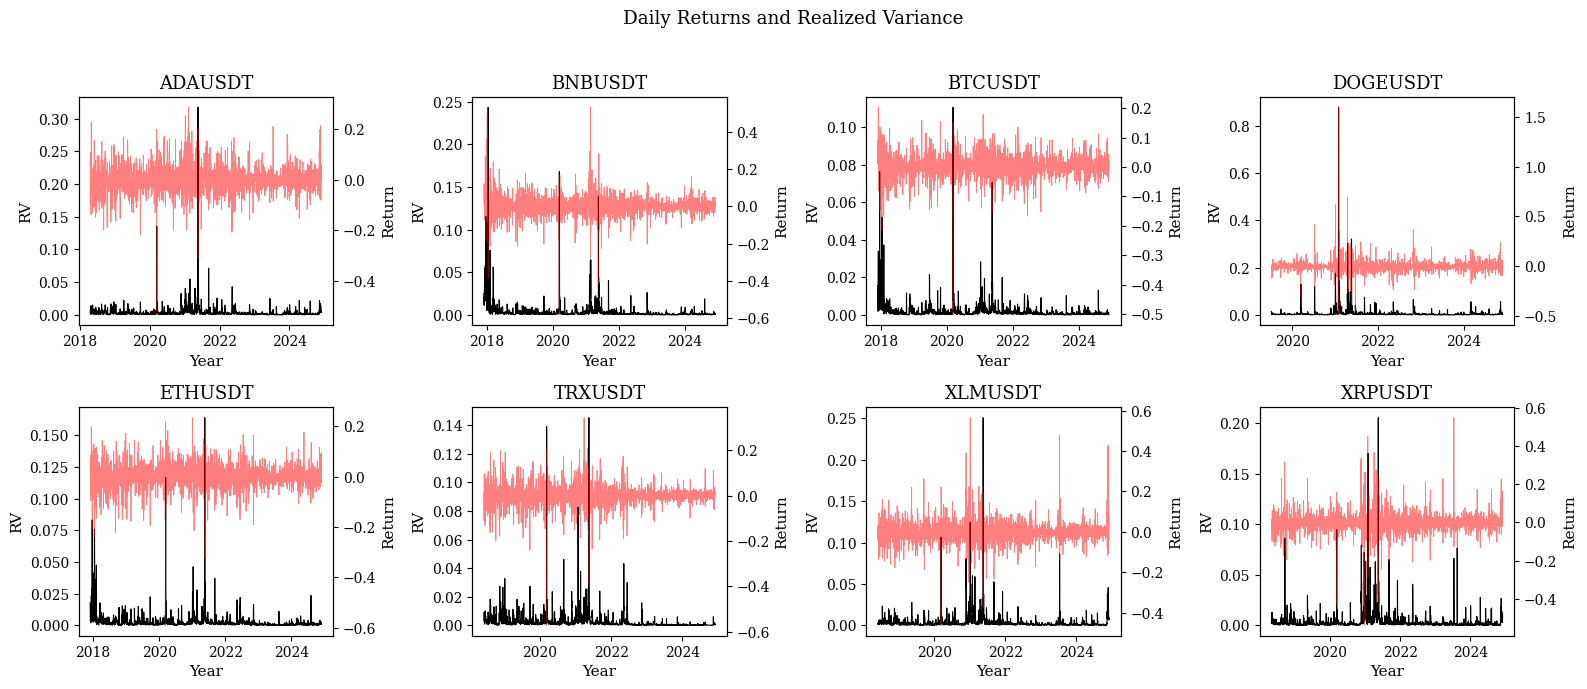

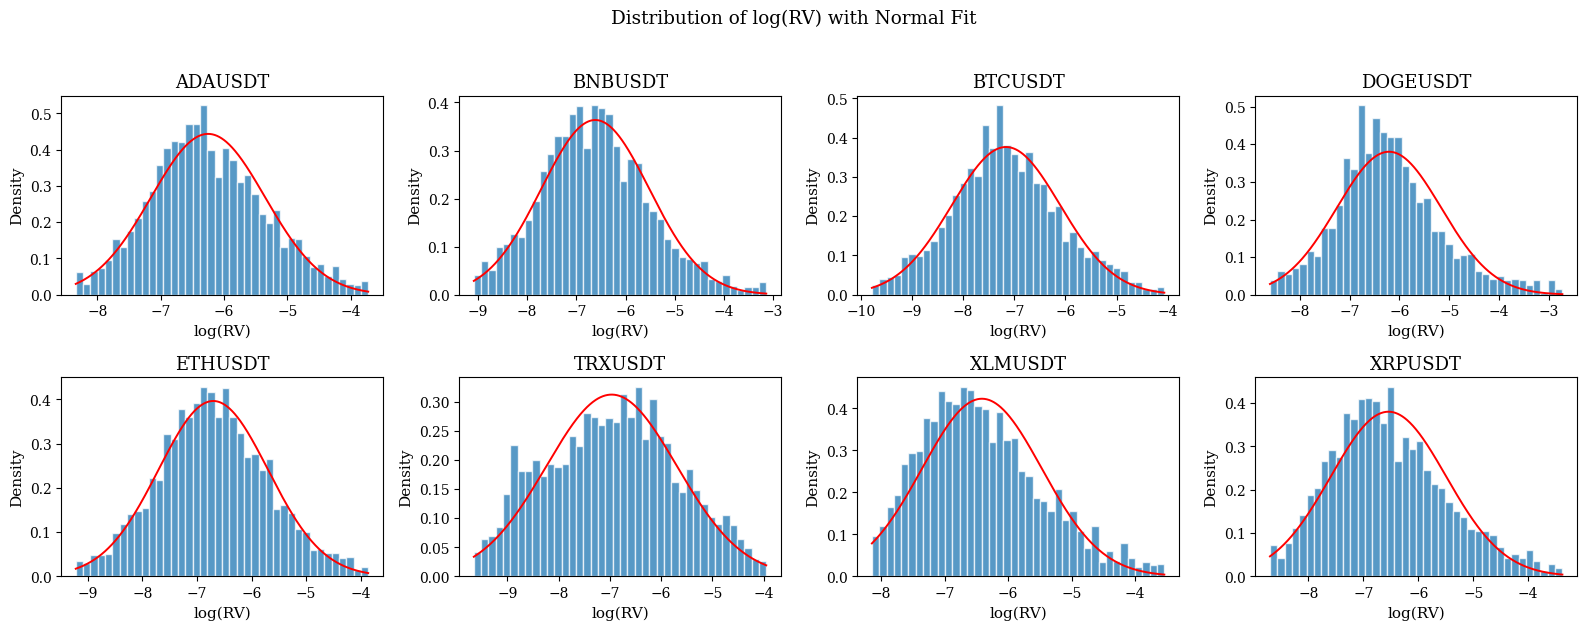

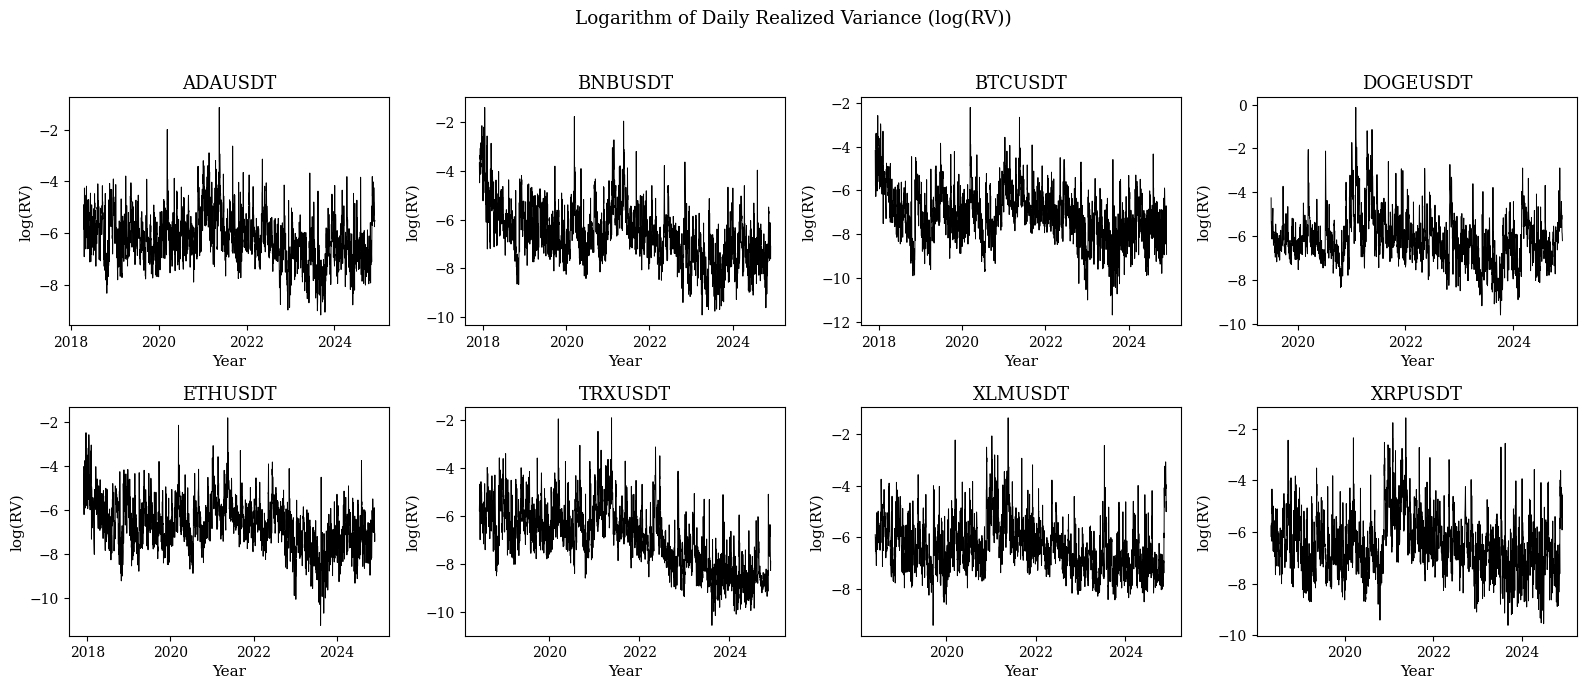

âœ… Todos os grÃ¡ficos e tabelas foram gerados com sucesso em: Results


In [70]:
# ------------------------------------------------------------

# Escolha do horizonte

# ------------------------------------------------------------

HORIZON = 1  # altere para 1, 7 ou 30



if HORIZON not in HORIZON_CONFIG:

    raise ValueError(f"Horizonte invÃ¡lido: {HORIZON}. Use 1, 7 ou 30.")



config = HORIZON_CONFIG[HORIZON]



DATA_PATH = Path(config.base_input_dir)

OUTPUT_DIR = eda_output_dir

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)



RV_COLUMN = "RV"

DATE_COLUMN = "Data"

RETURN_COLUMN = "retorno_diario"   # se nÃ£o existir, tenta inferir



OUTPUT_TABLE_LOGRV = OUTPUT_DIR / "attachment_2_log(RV)_summary_statistics.xlsx"

OUTPUT_TABLE_SAMPLE_INFO = OUTPUT_DIR / "attachment_1_sample_period_summary.xlsx"



# valor mÃ­nimo para permitir log sem perder observaÃ§Ãµes

LOG_EPS = 1e-12





# ============================================================

# FUNÃ‡Ã•ES AUXILIARES

# ============================================================



def read_asset_file(file: Path) -> pd.DataFrame:

    df = pd.read_excel(file)



    if DATE_COLUMN not in df.columns:

        raise ValueError(f"{file.name}: coluna '{DATE_COLUMN}' nÃ£o encontrada.")



    df[DATE_COLUMN] = pd.to_datetime(df[DATE_COLUMN])

    return df.set_index(DATE_COLUMN).sort_index()





def fill_first_nan_return_with_zero(ret: pd.Series) -> pd.Series:

    """

    Se a sÃ©rie de retornos vier com NaN apenas na primeira posiÃ§Ã£o

    (caso tÃ­pico de diff/log-diff), preenche com 0 para nÃ£o perder

    a primeira data em alinhamentos e grÃ¡ficos.

    """

    ret = pd.to_numeric(ret, errors="coerce").copy()



    if len(ret) > 0 and pd.isna(ret.iloc[0]):

        ret.iloc[0] = 0.0



    return ret





def pick_return_series(df: pd.DataFrame) -> pd.Series:

    if RETURN_COLUMN in df.columns:

        return fill_first_nan_return_with_zero(df[RETURN_COLUMN])



    for c in ["Return", "ret", "returns", "log_return", "logret"]:

        if c in df.columns:

            return fill_first_nan_return_with_zero(df[c])



    for pc in ["Close", "close", "Adj Close", "PRICE"]:

        if pc in df.columns:

            px = pd.to_numeric(df[pc], errors="coerce")

            ret = np.log(px).diff()

            return fill_first_nan_return_with_zero(ret)



    return pd.Series(index=df.index, dtype=float)





def build_log_rv_series(rv: pd.Series, eps: float = LOG_EPS) -> pd.Series:

    """

    Gera log(RV) sem perder observaÃ§Ãµes vÃ¡lidas.

    Se RV <= 0, usa eps antes do log.

    """

    rv = pd.to_numeric(rv, errors="coerce").copy()



    log_rv = pd.Series(index=rv.index, dtype=float)



    valid_mask = rv.notna()

    rv_valid = rv.loc[valid_mask].clip(lower=eps)



    log_rv.loc[valid_mask] = np.log(rv_valid)



    return log_rv





def compute_statistics(series: pd.Series) -> dict:

    series = pd.to_numeric(series, errors="coerce").dropna()



    if series.empty:

        return {

            "Mean": np.nan,

            "Std.Dev.": np.nan,

            "Kurtosis": np.nan,

            "Skewness": np.nan,

            "Median": np.nan,

            "25%-quantile": np.nan,

            "75%-quantile": np.nan,

            "AutoCorr(lag=1)": np.nan,

            "Jarque-Bera": np.nan,

            "Obs.": 0,

        }



    jb_stat, jb_p = jarque_bera(series) if len(series) >= 2 else (np.nan, np.nan)

    jb_str = (

        f"{jb_stat:.2f}" + ("***" if jb_p < 0.01 else "")

        if np.isfinite(jb_stat) else np.nan

    )



    return {

        "Mean": series.mean(),

        "Std.Dev.": series.std(),

        "Kurtosis": kurtosis(series, fisher=True),

        "Skewness": skew(series),

        "Median": series.median(),

        "25%-quantile": series.quantile(0.25),

        "75%-quantile": series.quantile(0.75),

        "AutoCorr(lag=1)": series.autocorr(lag=1),

        "Jarque-Bera": jb_str,

        "Obs.": int(series.shape[0]),

    }





def export_sample_period_table(asset_info: dict, output_path: Path) -> pd.DataFrame:

    """

    Exporta uma planilha Excel com a estrutura da tabela da figura:

    linhas = Initial date, Final date, Total observations

    colunas = ativos.



    ObservaÃ§Ã£o: "Total observations" usa a quantidade de valores nÃ£o nulos

    em RV. Se vocÃª quiser contar todas as linhas do arquivo, troque

    `rv.notna().sum()` por `len(df)` no loop principal.

    """

    summary_sample = pd.DataFrame(asset_info)

    summary_sample.to_excel(output_path)

    return summary_sample





# ============================================================

# LEITURA DOS DADOS

# ============================================================



rv_dict, ret_dict, stats_logrv, sample_info = {}, {}, {}, {}



files_all = sorted(DATA_PATH.glob("*_daily.xlsx"))
if not files_all:
    raise FileNotFoundError(f"Nenhum arquivo '*_daily.xlsx' encontrado em {DATA_PATH}.")

allowed_symbols = set(SYMBOLS)
files = [f for f in files_all if f.stem.split("_")[0] in allowed_symbols]
if not files:
    raise FileNotFoundError(
        f"Nenhum arquivo de ativos configurados em SYMBOLS foi encontrado em {DATA_PATH}. "
        f"SYMBOLS={sorted(allowed_symbols)}"
    )




for file in files:

    asset = file.stem.split("_")[0]

    df = read_asset_file(file)



    rv = pd.to_numeric(df[RV_COLUMN], errors="coerce")

    log_rv = build_log_rv_series(rv, eps=LOG_EPS)

    ret = pick_return_series(df)



    rv_dict[asset] = rv

    ret_dict[asset] = ret



    sample_info[asset] = {

        "Initial date": df.index.min().strftime("%d/%m/%Y") if len(df.index) else np.nan,

        "Final date": df.index.max().strftime("%d/%m/%Y") if len(df.index) else np.nan,

        "Total observations": int(rv.notna().sum()),

    }



    # estatÃ­sticas usando todos os pontos vÃ¡lidos de log(RV)

    stats_logrv[asset] = compute_statistics(log_rv)





# ============================================================

# TABELA DE ESTATÃSTICAS

# ============================================================



summary_logrv = pd.DataFrame(stats_logrv)

summary_logrv.to_excel(OUTPUT_TABLE_LOGRV)



summary_sample = export_sample_period_table(sample_info, OUTPUT_TABLE_SAMPLE_INFO)



print(f"âœ… Tabela de estatÃ­sticas de log(RV) gerada em: {OUTPUT_DIR}")

print(f"âœ… Tabela com perÃ­odo amostral e nÃºmero de observaÃ§Ãµes gerada em: {OUTPUT_TABLE_SAMPLE_INFO}")





# ============================================================

# CONFIGURAÃ‡ÃƒO DO GRID

# ============================================================



n_assets = len(rv_dict)

n_cols = 4

n_rows = int(np.ceil(n_assets / n_cols))





# ============================================================

# FIGURA 1 â€” RETORNO Ã— RV

# ============================================================



fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.5 * n_rows))

axes = np.array(axes).reshape(-1)



for i, asset in enumerate(rv_dict.keys()):

    df_plot = pd.concat(

        [rv_dict[asset].rename("RV"), ret_dict[asset].rename("RET")],

        axis=1

    )



    ax1 = axes[i]

    ax2 = ax1.twinx()



    rv_mask = df_plot["RV"].notna()

    ret_mask = df_plot["RET"].notna()



    ax1.plot(

        df_plot.index[rv_mask],

        df_plot.loc[rv_mask, "RV"],

        color="black",

        linewidth=0.8

    )



    ax2.plot(

        df_plot.index[ret_mask],

        df_plot.loc[ret_mask, "RET"],

        color="red",

        alpha=0.5,

        linewidth=0.6

    )



    ax1.set_title(asset)

    ax1.set_ylabel("RV")

    ax2.set_ylabel("Return")



    ax1.set_xlabel("Year")

    ax1.xaxis.set_major_locator(mdates.YearLocator(base=2))

    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))



for j in range(i + 1, len(axes)):

    fig.delaxes(axes[j])



fig.suptitle("Daily Returns and Realized Variance")

fig.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(OUTPUT_DIR / "attachment_3_returns_and_RV_time_series.png", dpi=300)

plt.show()





# ============================================================

# FIGURA 2 â€” DISTRIBUIÃ‡ÃƒO CONJUNTA DE log(RV)

# ============================================================



fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.2 * n_rows))

axes = np.array(axes).reshape(-1)



for i, (asset, rv) in enumerate(rv_dict.items()):

    ax = axes[i]



    log_rv = build_log_rv_series(rv, eps=LOG_EPS).dropna()



    # mantÃ©m sua lÃ³gica de poda visual para o histograma

    q1, q99 = log_rv.quantile([0.01, 0.99])

    log_rv_hist = log_rv[(log_rv >= q1) & (log_rv <= q99)]



    mu, sigma = log_rv_hist.mean(), log_rv_hist.std(ddof=1)



    ax.hist(log_rv_hist, bins=40, density=True, alpha=0.75, edgecolor="white")

    x = np.linspace(log_rv_hist.min(), log_rv_hist.max(), 500)

    ax.plot(x, norm.pdf(x, mu, sigma), "r-", linewidth=1.4)



    ax.set_title(asset)

    ax.set_xlabel("log(RV)")

    ax.set_ylabel("Density")



for j in range(i + 1, len(axes)):

    fig.delaxes(axes[j])



fig.suptitle("Distribution of log(RV) with Normal Fit")

fig.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(OUTPUT_DIR / "attachment_5_log(RV)_distribution_all_assets.png", dpi=300)

plt.show()





# ============================================================

# FIGURA 3 â€” log(RV) NO TEMPO

# ============================================================



fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.5 * n_rows))

axes = np.array(axes).reshape(-1)



for i, (asset, rv) in enumerate(rv_dict.items()):

    ax = axes[i]



    log_rv = build_log_rv_series(rv, eps=LOG_EPS)

    mask = log_rv.notna()



    ax.plot(log_rv.index[mask], log_rv.loc[mask], color="black", linewidth=0.7)



    ax.set_title(asset)

    ax.set_ylabel("log(RV)")

    ax.set_xlabel("Year")



    ax.xaxis.set_major_locator(mdates.YearLocator(base=2))

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))



for j in range(i + 1, len(axes)):

    fig.delaxes(axes[j])



fig.suptitle("Logarithm of Daily Realized Variance (log(RV))")

fig.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(OUTPUT_DIR / "attachment_4_log(RV)_time_series.png", dpi=300)

plt.show()



print(f"âœ… Todos os grÃ¡ficos e tabelas foram gerados com sucesso em: {OUTPUT_DIR}")

# Fuzzy HAR Train & Test

## Run Model

In [71]:
def run_fuzzy_for_symbol(symbol: str, horizon: int) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Roda apenas o pipeline fuzzy HAR para um sÃ­mbolo e horizonte.
    """
    if horizon not in HORIZON_CONFIG:
        raise ValueError(f"Horizonte invÃ¡lido: {horizon}. Use 1, 7 ou 30.")

    config = HORIZON_CONFIG[horizon]

    # 1) Paths
    paths = _build_io_paths(
        symbol=symbol,
        base_input_dir=config.base_input_dir,
        base_output_dir=config.base_output_dir,
    )

    # Garante que a pasta de saÃ­da do sÃ­mbolo exista
    os.makedirs(paths["symbol_out_dir"], exist_ok=True)

    # 2) Carrega e prepara os dados
    df_train, df_test = _load_and_prepare_base_data(
        insample_path=paths["insample_path"],
        outsample_path=paths["outsample_path"],
    )

    # 3) SeleÃ§Ã£o de hiperparÃ¢metros apenas para HAR
    best_rules_number_har, best_ze_har = _select_best_har_hyperparameters(
        df_train=df_train,
        df_test=df_test,
        symbol_out_dir=paths["symbol_out_dir"],
        rules_grid=rules_grid,
        ze=ze,
        lamb=lamb,
        alfa=alfa,
        week_len=week_len,
        month_len=month_len,
)

    # 4) Executa apenas o bloco HAR
    df_train, df_test = _run_best_har_block(
        df_train=df_train,
        df_test=df_test,
        best_rules_number_har=best_rules_number_har,
        best_ze_har=best_ze_har,
        lamb=lamb,
        alfa=alfa,
        week_len=week_len,
        month_len=month_len,
    )

    # 5) Salva outputs
    train_out_path, test_out_path = _save_outputs(
        df_train=df_train,
        df_test=df_test,
        symbol=symbol,
        horizon=horizon,
        symbol_out_dir=paths["symbol_out_dir"],
    )

    print(
        f"[{symbol} | t+{horizon} | HAR only] concluÃ­do.\n"
        f"Train: {train_out_path}\n"
        f"Test:  {test_out_path}\n"
        f"Best HAR: r={best_rules_number_har}, ze={best_ze_har}"
    )

    return df_train, df_test

In [72]:
# Usa exclusivamente a lista definida em Parameters
symbols = list(SYMBOLS)

all_results = {}

for horizon in [1, 7, 30]:
    all_results[horizon] = {}
    for sym in symbols:
        df_tr, df_te = run_fuzzy_for_symbol(sym, horizon)
        all_results[horizon][sym] = {"train": df_tr, "test": df_te}

[ADAUSDT | t+1 | HAR only] concluÃ­do.
Train: Others\Predictions\Fuzzy HAR\RV_t+1\ADAUSDT\ADAUSDT_tplus1_train_with_fuzzy.xlsx
Test:  Others\Predictions\Fuzzy HAR\RV_t+1\ADAUSDT\ADAUSDT_tplus1_test_with_fuzzy.xlsx
Best HAR: r=6, ze=1.0
[BNBUSDT | t+1 | HAR only] concluÃ­do.
Train: Others\Predictions\Fuzzy HAR\RV_t+1\BNBUSDT\BNBUSDT_tplus1_train_with_fuzzy.xlsx
Test:  Others\Predictions\Fuzzy HAR\RV_t+1\BNBUSDT\BNBUSDT_tplus1_test_with_fuzzy.xlsx
Best HAR: r=6, ze=1.0
[BTCUSDT | t+1 | HAR only] concluÃ­do.
Train: Others\Predictions\Fuzzy HAR\RV_t+1\BTCUSDT\BTCUSDT_tplus1_train_with_fuzzy.xlsx
Test:  Others\Predictions\Fuzzy HAR\RV_t+1\BTCUSDT\BTCUSDT_tplus1_test_with_fuzzy.xlsx
Best HAR: r=6, ze=1.0


R callback write-console: In addition:   
R callback write-console: There were 50 or more warnings (use warnings() to see the first 50)  
R callback write-console: 
  
R callback write-console: In addition:   
R callback write-console: There were 50 or more warnings (use warnings() to see the first 50)  
R callback write-console: 
  
R callback write-console: In addition:   
R callback write-console: There were 50 or more warnings (use warnings() to see the first 50)  
R callback write-console: 
  
R callback write-console: In addition:   
R callback write-console: There were 50 or more warnings (use warnings() to see the first 50)  
R callback write-console: 
  
R callback write-console: In addition:   
R callback write-console: There were 50 or more warnings (use warnings() to see the first 50)  
R callback write-console: 
  


[DOGEUSDT | t+1 | HAR only] concluÃ­do.
Train: Others\Predictions\Fuzzy HAR\RV_t+1\DOGEUSDT\DOGEUSDT_tplus1_train_with_fuzzy.xlsx
Test:  Others\Predictions\Fuzzy HAR\RV_t+1\DOGEUSDT\DOGEUSDT_tplus1_test_with_fuzzy.xlsx
Best HAR: r=4, ze=1.0
[ETHUSDT | t+1 | HAR only] concluÃ­do.
Train: Others\Predictions\Fuzzy HAR\RV_t+1\ETHUSDT\ETHUSDT_tplus1_train_with_fuzzy.xlsx
Test:  Others\Predictions\Fuzzy HAR\RV_t+1\ETHUSDT\ETHUSDT_tplus1_test_with_fuzzy.xlsx
Best HAR: r=6, ze=1.0
[TRXUSDT | t+1 | HAR only] concluÃ­do.
Train: Others\Predictions\Fuzzy HAR\RV_t+1\TRXUSDT\TRXUSDT_tplus1_train_with_fuzzy.xlsx
Test:  Others\Predictions\Fuzzy HAR\RV_t+1\TRXUSDT\TRXUSDT_tplus1_test_with_fuzzy.xlsx
Best HAR: r=6, ze=1.0
[XLMUSDT | t+1 | HAR only] concluÃ­do.
Train: Others\Predictions\Fuzzy HAR\RV_t+1\XLMUSDT\XLMUSDT_tplus1_train_with_fuzzy.xlsx
Test:  Others\Predictions\Fuzzy HAR\RV_t+1\XLMUSDT\XLMUSDT_tplus1_test_with_fuzzy.xlsx
Best HAR: r=6, ze=1.0
[XRPUSDT | t+1 | HAR only] concluÃ­do.
Train: Other

R callback write-console: In addition:   
R callback write-console: There were 50 or more warnings (use warnings() to see the first 50)  
R callback write-console: 
  
R callback write-console: In addition:   
R callback write-console: There were 50 or more warnings (use warnings() to see the first 50)  
R callback write-console: 
  
R callback write-console: In addition:   
R callback write-console: There were 50 or more warnings (use warnings() to see the first 50)  
R callback write-console: 
  


[DOGEUSDT | t+7 | HAR only] concluÃ­do.
Train: Others\Predictions\Fuzzy HAR\RV_t+7\DOGEUSDT\DOGEUSDT_tplus7_train_with_fuzzy.xlsx
Test:  Others\Predictions\Fuzzy HAR\RV_t+7\DOGEUSDT\DOGEUSDT_tplus7_test_with_fuzzy.xlsx
Best HAR: r=2, ze=1.0
[ETHUSDT | t+7 | HAR only] concluÃ­do.
Train: Others\Predictions\Fuzzy HAR\RV_t+7\ETHUSDT\ETHUSDT_tplus7_train_with_fuzzy.xlsx
Test:  Others\Predictions\Fuzzy HAR\RV_t+7\ETHUSDT\ETHUSDT_tplus7_test_with_fuzzy.xlsx
Best HAR: r=6, ze=1.0
[TRXUSDT | t+7 | HAR only] concluÃ­do.
Train: Others\Predictions\Fuzzy HAR\RV_t+7\TRXUSDT\TRXUSDT_tplus7_train_with_fuzzy.xlsx
Test:  Others\Predictions\Fuzzy HAR\RV_t+7\TRXUSDT\TRXUSDT_tplus7_test_with_fuzzy.xlsx
Best HAR: r=6, ze=1.0
[XLMUSDT | t+7 | HAR only] concluÃ­do.
Train: Others\Predictions\Fuzzy HAR\RV_t+7\XLMUSDT\XLMUSDT_tplus7_train_with_fuzzy.xlsx
Test:  Others\Predictions\Fuzzy HAR\RV_t+7\XLMUSDT\XLMUSDT_tplus7_test_with_fuzzy.xlsx
Best HAR: r=6, ze=1.0
[XRPUSDT | t+7 | HAR only] concluÃ­do.
Train: Other

R callback write-console: In addition:   
R callback write-console: There were 50 or more warnings (use warnings() to see the first 50)  
R callback write-console: 
  
R callback write-console: In addition:   
R callback write-console: There were 50 or more warnings (use warnings() to see the first 50)  
R callback write-console: 
  
R callback write-console: In addition:   
R callback write-console: There were 50 or more warnings (use warnings() to see the first 50)  
R callback write-console: 
  
R callback write-console: In addition:   
R callback write-console: There were 50 or more warnings (use warnings() to see the first 50)  
R callback write-console: 
  
R callback write-console: In addition:   
R callback write-console: There were 50 or more warnings (use warnings() to see the first 50)  
R callback write-console: 
  


[DOGEUSDT | t+30 | HAR only] concluÃ­do.
Train: Others\Predictions\Fuzzy HAR\RV_t+30\DOGEUSDT\DOGEUSDT_tplus30_train_with_fuzzy.xlsx
Test:  Others\Predictions\Fuzzy HAR\RV_t+30\DOGEUSDT\DOGEUSDT_tplus30_test_with_fuzzy.xlsx
Best HAR: r=4, ze=1.0
[ETHUSDT | t+30 | HAR only] concluÃ­do.
Train: Others\Predictions\Fuzzy HAR\RV_t+30\ETHUSDT\ETHUSDT_tplus30_train_with_fuzzy.xlsx
Test:  Others\Predictions\Fuzzy HAR\RV_t+30\ETHUSDT\ETHUSDT_tplus30_test_with_fuzzy.xlsx
Best HAR: r=6, ze=1.0
[TRXUSDT | t+30 | HAR only] concluÃ­do.
Train: Others\Predictions\Fuzzy HAR\RV_t+30\TRXUSDT\TRXUSDT_tplus30_train_with_fuzzy.xlsx
Test:  Others\Predictions\Fuzzy HAR\RV_t+30\TRXUSDT\TRXUSDT_tplus30_test_with_fuzzy.xlsx
Best HAR: r=6, ze=1.0
[XLMUSDT | t+30 | HAR only] concluÃ­do.
Train: Others\Predictions\Fuzzy HAR\RV_t+30\XLMUSDT\XLMUSDT_tplus30_train_with_fuzzy.xlsx
Test:  Others\Predictions\Fuzzy HAR\RV_t+30\XLMUSDT\XLMUSDT_tplus30_test_with_fuzzy.xlsx
Best HAR: r=6, ze=1.0
[XRPUSDT | t+30 | HAR only] con

# HAR Models Train & Test

In [73]:
pd.set_option("display.max_columns", 120)

pd.set_option("display.width", 160)

np.seterr(all="ignore")



# ============================================================

# CONFIGURAÃ‡ÃƒO

# ============================================================



HORIZON_FOLDERS = ["RV_t+1", "RV_t+7", "RV_t+30"]



# Modelos a avaliar

MODELOS = ["HAR", "HAR-CJ", "HAR-TCJ", "LHAR-TCJ", "HAR-SJ"]

# MODELOS = ["HAR"]  # use isso se quiser testar sÃ³ HAR primeiro



# EstratÃ©gia OOS

SCHEME = "rolling"         # "expanding" ou "rolling"

ROLLING_WINDOW = 730       # usado apenas se SCHEME="rolling"

REESTIMAR_A_CADA_PASSO = True



# SeguranÃ§a numÃ©rica para QLIKE

EPS = 1e-12



# PadrÃµes de nomes esperados

INSAMPLE_SUFFIX = "_5m_daily_insample.xlsx"

OOS_SUFFIX = "_5m_daily_outofsample.xlsx"



# Regressoras esperadas por modelo

model_variables_dict = {

    "HAR":      ["RV_t-1", "RV_t-7", "RV_t-30"],

    "HAR-CJ":   ["C_d", "C_d_7d", "C_d_30d", "J_t"],

    "HAR-TCJ":  ["TC_d", "TC_d_7d", "TC_d_30d", "TJ_t"],

    "LHAR-TCJ": ["TC_d", "TC_d_7d", "TC_d_30d", "TJ_t", "exp_r-_d"],

    "HAR-SJ":   ["RV_t-7", "RV_t-30", "BPV_d", "exp_SJ+_t", "exp_SJ-_t"],

}



# ============================================================

# FUNÃ‡Ã•ES AUXILIARES

# ============================================================



def mse(y, f):

    return float(np.mean((np.asarray(y, float) - np.asarray(f, float)) ** 2))



def mae(y, f):

    return float(np.mean(np.abs(np.asarray(y, float) - np.asarray(f, float))))



def rmse(y, f):

    return float(np.sqrt(np.mean((np.asarray(y, float) - np.asarray(f, float)) ** 2)))



def qlike(y, f):

    y_pos = np.clip(np.asarray(y, float), EPS, None)

    f_pos = np.clip(np.asarray(f, float), EPS, None)

    return float(np.mean(np.log(f_pos) + y_pos / f_pos))



def _save_ts_plot(x, series, title, ylabel, out_path):

    fig = plt.figure()

    plt.plot(x, series)

    plt.title(title)

    plt.xlabel("Data")

    plt.ylabel(ylabel)

    plt.tight_layout()

    fig.savefig(out_path, dpi=150, bbox_inches="tight")

    plt.close(fig)



def _save_scatter(x, y, title, xlabel, ylabel, out_path):

    fig = plt.figure()

    plt.scatter(x, y, s=10)

    plt.title(title)

    plt.xlabel(xlabel)

    plt.ylabel(ylabel)

    plt.tight_layout()

    fig.savefig(out_path, dpi=150, bbox_inches="tight")

    plt.close(fig)



def gerar_graficos_oos(test_df, y_test, yhat_test, rep_dir, base_name, model_name):

    plots_dir = rep_dir / "plots_oos"

    plots_dir.mkdir(parents=True, exist_ok=True)



    dates = test_df["Data"].values

    _save_ts_plot(

        dates, y_test,

        f"OOS â€” Target â€” {base_name} [{model_name}]",

        "Target",

        plots_dir / f"{base_name}__{model_name}__oos_target.png"

    )

    _save_ts_plot(

        dates, yhat_test,

        f"OOS â€” Prediction â€” {base_name} [{model_name}]",

        "Prediction",

        plots_dir / f"{base_name}__{model_name}__oos_prediction.png"

    )

    _save_scatter(

        y_test, yhat_test,

        f"OOS â€” Target vs Prediction â€” {base_name} [{model_name}]",

        "Target", "Prediction",

        plots_dir / f"{base_name}__{model_name}__oos_target_vs_pred.png"

    )

    _save_ts_plot(

        dates, np.asarray(y_test) - np.asarray(yhat_test),

        f"OOS â€” ResÃ­duos â€” {base_name} [{model_name}]",

        "ResÃ­duo",

        plots_dir / f"{base_name}__{model_name}__oos_residuos.png"

    )



def _standardize_input_df(df: pd.DataFrame, df_name: str) -> pd.DataFrame:

    """

    Padroniza nomes de colunas para o formato esperado por este cÃ³digo.

    """

    out = df.copy()



    # Data

    if "Data" not in out.columns and "Date" in out.columns:

        out = out.rename(columns={"Date": "Data"})



    # target

    if "target" not in out.columns and "Target" in out.columns:

        out = out.rename(columns={"Target": "target"})



    # retorno_diario Ã© Ãºtil para outputs/grÃ¡ficos; se nÃ£o existir, cria vazio

    if "retorno_diario" not in out.columns:

        out["retorno_diario"] = np.nan



    required = {"Data", "target"}

    missing = required - set(out.columns)

    if missing:

        raise ValueError(f"{df_name}: faltam colunas obrigatÃ³rias: {missing}")



    out["Data"] = pd.to_datetime(out["Data"], errors="coerce")

    out = out.dropna(subset=["Data"]).sort_values("Data").reset_index(drop=True)



    return out



def _ensure_derived_columns(df: pd.DataFrame) -> pd.DataFrame:

    """

    Deriva apenas colunas exponenciadas que o script original jÃ¡ sabia criar.

    """

    out = df.copy()



    if "exp_r-_d" not in out.columns and "r-_d" in out.columns:

        out["exp_r-_d"] = np.exp(out["r-_d"])



    if "exp_SJ+_t" not in out.columns and "SJ+_t" in out.columns:

        out["exp_SJ+_t"] = np.exp(out["SJ+_t"])



    if "exp_SJ-_t" not in out.columns and "SJ-_t" in out.columns:

        out["exp_SJ-_t"] = np.exp(out["SJ-_t"])



    return out



def _extract_symbol_from_filename(filename: str, suffix: str) -> str:

    if not filename.endswith(suffix):

        raise ValueError(f"Arquivo com nome inesperado: {filename}")

    return filename[:-len(suffix)]



def _build_output_paths(horizon_folder: str, symbol: str):

    """

    Exemplo:

    /content/drive/MyDrive/ProductionFuzzyHARPipeline/Others/Predictions_RV_t+1/BTCUSDT

    """

    symbol_root = (

        get_prediction_output_dir_from_folder(horizon_folder)

        / symbol

    )

    train_dir = symbol_root / "insample_train"

    oos_dir = symbol_root / "out-of-sample"



    train_dir.mkdir(parents=True, exist_ok=True)

    oos_dir.mkdir(parents=True, exist_ok=True)



    return {

        "symbol_root": symbol_root,

        "train_dir": train_dir,

        "oos_dir": oos_dir,

    }



# ============================================================

# NÃšCLEO: RODA OOS PARA UM PAR (TREINO + TESTE)

# ============================================================



def oos_modelos_por_par(

    train_file: str | Path,

    test_file: str | Path,

    modelos: list[str] | None = None,

    scheme: str = "expanding",

    rolling_window: int | None = None,

    reestimar_a_cada_passo: bool = True,

) -> None:

    """

    Roda os modelos OLS OOS usando:

      - train_file = insample

      - test_file  = out_of_sample



    Sem refazer split interno.

    """

    train_path = Path(train_file)

    test_path = Path(test_file)



    # Identifica horizonte e sÃ­mbolo

    # Esperado:

    # .../RV_t+1/insample/SYMBOL_5m_daily_insample.xlsx

    # .../RV_t+1/out_of_sample/SYMBOL_5m_daily_outofsample.xlsx

    horizon_folder = train_path.parent.parent.name

    if horizon_folder != test_path.parent.parent.name:

        raise ValueError(

            f"Treino e teste pertencem a horizontes diferentes: "

            f"{horizon_folder} vs {test_path.parent.parent.name}"

        )



    symbol_train = _extract_symbol_from_filename(train_path.name, INSAMPLE_SUFFIX)

    symbol_test = _extract_symbol_from_filename(test_path.name, OOS_SUFFIX)



    if symbol_train != symbol_test:

        raise ValueError(

            f"SÃ­mbolo do treino difere do teste: {symbol_train} vs {symbol_test}"

        )



    symbol = symbol_train

    base_name = symbol



    outputs = _build_output_paths(horizon_folder, symbol)



    # ---------- leitura ----------

    df_train = pd.read_excel(train_path)

    df_test = pd.read_excel(test_path)



    df_train = _standardize_input_df(df_train, f"Treino ({train_path.name})")

    df_test = _standardize_input_df(df_test, f"Teste ({test_path.name})")



    df_train = _ensure_derived_columns(df_train)

    df_test = _ensure_derived_columns(df_test)



    if modelos is None:

        modelos = list(model_variables_dict.keys())



    # ---------- roda modelo a modelo ----------

    for model_name in modelos:

        vars_needed = model_variables_dict[model_name]



        missing_cols = [

            c for c in vars_needed

            if c not in df_train.columns or c not in df_test.columns

        ]

        if missing_cols:

            print(

                f"âš ï¸ {symbol} | {horizon_folder} | {model_name}: "

                f"pulando (faltam colunas: {missing_cols})"

            )

            continue



        # filtra linhas vÃ¡lidas separadamente em treino e teste

        train_valid_mask = df_train[vars_needed].notna().all(axis=1) & df_train["target"].notna()

        test_valid_mask = df_test[vars_needed].notna().all(axis=1) & df_test["target"].notna()



        if not train_valid_mask.any():

            print(f"âš ï¸ {symbol} | {horizon_folder} | {model_name}: treino sem linhas vÃ¡lidas.")

            continue



        if not test_valid_mask.any():

            print(f"âš ï¸ {symbol} | {horizon_folder} | {model_name}: teste sem linhas vÃ¡lidas.")

            continue



        train_valid = df_train.loc[train_valid_mask].copy().reset_index(drop=True)

        test_valid = df_test.loc[test_valid_mask].copy().reset_index(drop=True)



        X_train0 = train_valid[vars_needed].copy()

        y_train0 = train_valid["target"].copy()



        X_test = test_valid[vars_needed].copy()

        y_test = test_valid["target"].copy()



        df_test_meta = test_valid[["Data", "retorno_diario"]].copy()

        test_dates = test_valid["Data"].values



        if X_train0.empty or X_test.empty:

            print(f"âš ï¸ {symbol} | {horizon_folder} | {model_name}: treino ou teste vazios.")

            continue



        # ---------- (1) Fit no treino inteiro ----------

        Xc_train = sm.add_constant(X_train0, has_constant="add")

        mdl_train = sm.OLS(y_train0, Xc_train).fit(

            cov_type="HAC",

            cov_kwds={"maxlags": 5},

            use_t=True

        )

        yhat_train = mdl_train.predict(Xc_train).values



        # ---------- salva treino ----------

        train_sheet = train_valid[["Data", "retorno_diario"]].copy()

        train_sheet["Target"] = y_train0.values

        train_sheet[f"{model_name} train prediction"] = yhat_train



        train_out = outputs["train_dir"] / f"{base_name}__{model_name}__insample_train.xlsx"

        train_sheet.to_excel(train_out, index=False)



        # ---------- (2) previsÃ£o OOS ----------

        yhat_oos = np.full(len(X_test), np.nan, dtype=float)



        if not reestimar_a_cada_passo:

            Xc_test = sm.add_constant(X_test, has_constant="add")

            yhat_oos = mdl_train.predict(Xc_test).values

        else:

            # histÃ³rico total elegÃ­vel = treino vÃ¡lido + teste vÃ¡lido

            # a cada data de teste d, usa apenas observaÃ§Ãµes com Data < d

            all_valid = pd.concat([train_valid, test_valid], axis=0, ignore_index=True)

            all_valid = all_valid.sort_values("Data").reset_index(drop=True)



            X_all = all_valid[vars_needed].copy()

            y_all = all_valid["target"].copy()

            data_values = all_valid["Data"].values



            scheme_l = (scheme or "expanding").lower()

            use_rolling = (

                (scheme_l == "rolling") and

                (rolling_window is not None) and

                (int(rolling_window) > 0)

            )

            roll_n = int(rolling_window) if use_rolling else None



            for i, d in enumerate(test_dates):

                hist_mask = (data_values < d)



                if not hist_mask.any():

                    x_row = X_test.iloc[i:i+1, :]

                    Xc_row = sm.add_constant(x_row, has_constant="add")

                    yhat_oos[i] = mdl_train.predict(Xc_row).item()

                    continue



                if use_rolling:

                    hist_idx = np.flatnonzero(hist_mask)

                    if len(hist_idx) > roll_n:

                        hist_idx = hist_idx[-roll_n:]

                    X_hist = X_all.iloc[hist_idx, :]

                    y_hist = y_all.iloc[hist_idx]

                else:

                    X_hist = X_all.loc[hist_mask, :]

                    y_hist = y_all.loc[hist_mask]



                if X_hist.empty:

                    x_row = X_test.iloc[i:i+1, :]

                    Xc_row = sm.add_constant(x_row, has_constant="add")

                    yhat_oos[i] = mdl_train.predict(Xc_row).item()

                    continue



                Xc_hist = sm.add_constant(X_hist, has_constant="add")

                mdl_hist = sm.OLS(y_hist, Xc_hist).fit(

                    cov_type="HAC",

                    cov_kwds={"maxlags": 5},

                    use_t=True

                )



                x_row = X_test.iloc[i:i+1, :]

                Xc_row = sm.add_constant(x_row, has_constant="add")

                yhat_oos[i] = mdl_hist.predict(Xc_row).item()



        # ---------- saÃ­das OOS ----------

        out_pred = outputs["oos_dir"] / f"{base_name}__{model_name}__oos_predictions.xlsx"



        saida = df_test_meta.copy()

        saida["Target"] = y_test.values

        saida[f"{model_name} OOS prediction"] = yhat_oos

        saida.to_excel(out_pred, index=False)



        print(

            f"âœ… {symbol} | {horizon_folder} | {model_name}: "

            f"OOS salvo em {out_pred}"

        )



# ============================================================

# DESCOBRE OS PARES INSAMPLE / OUT_OF_SAMPLE

# ============================================================



def encontrar_pares_por_horizonte(horizon_folder: str):

    base_input_dir = get_input_dir_from_folder(horizon_folder)

    ins_dir = base_input_dir / "insample"

    oos_dir = base_input_dir / "out_of_sample"



    if not ins_dir.exists():

        raise FileNotFoundError(f"Pasta nÃ£o encontrada: {ins_dir}")

    if not oos_dir.exists():

        raise FileNotFoundError(f"Pasta nÃ£o encontrada: {oos_dir}")



    ins_files = sorted(ins_dir.glob(f"*{INSAMPLE_SUFFIX}"))

    oos_files = sorted(oos_dir.glob(f"*{OOS_SUFFIX}"))



    ins_map = {

        _extract_symbol_from_filename(f.name, INSAMPLE_SUFFIX): f

        for f in ins_files

    }

    oos_map = {

        _extract_symbol_from_filename(f.name, OOS_SUFFIX): f

        for f in oos_files

    }



    common_symbols = sorted(set(ins_map) & set(oos_map))

    missing_in_oos = sorted(set(ins_map) - set(oos_map))

    missing_in_ins = sorted(set(oos_map) - set(ins_map))



    if missing_in_oos:

        print(f"âš ï¸ {horizon_folder}: sem arquivo de teste para: {missing_in_oos}")

    if missing_in_ins:

        print(f"âš ï¸ {horizon_folder}: sem arquivo de treino para: {missing_in_ins}")



    pairs = [(sym, ins_map[sym], oos_map[sym]) for sym in common_symbols]

    return pairs



def oos_varios_horizontes_split_ready(
    horizon_folders: list[str] | None = None,
    modelos: list[str] | None = None,
    scheme: str = "expanding",
    rolling_window: int | None = None,
    reestimar_a_cada_passo: bool = True,
    symbols_to_run: list[str] | None = None,
):
    if horizon_folders is None:
        horizon_folders = HORIZON_FOLDERS
    if symbols_to_run is None:
        symbols_to_run = list(SYMBOLS)

    allowed_symbols = set(symbols_to_run)

    total_pairs = 0
    for horizon_folder in horizon_folders:
        pairs = encontrar_pares_por_horizonte(horizon_folder)
        pairs = [p for p in pairs if p[0] in allowed_symbols]

        print(f"▶️ {horizon_folder}: encontrados {len(pairs)} par(es) treino/teste.")
        total_pairs += len(pairs)

        for symbol, train_file, test_file in pairs:
            try:
                oos_modelos_por_par(
                    train_file=train_file,
                    test_file=test_file,
                    modelos=modelos,
                    scheme=scheme,
                    rolling_window=rolling_window,
                    reestimar_a_cada_passo=reestimar_a_cada_passo,
                )
            except Exception as e:
                print(f"❌ Erro em {symbol} | {horizon_folder}: {e}")

    print(f"\n✅ Concluído. Total de pares processados: {total_pairs}")

# ============================================================
# EXECUÇÃO
# ============================================================

oos_varios_horizontes_split_ready(
    horizon_folders=HORIZON_FOLDERS,
    modelos=MODELOS,
    scheme=SCHEME,
    rolling_window=ROLLING_WINDOW,
    reestimar_a_cada_passo=REESTIMAR_A_CADA_PASSO,
    symbols_to_run=SYMBOLS,
)

▶️ RV_t+1: encontrados 8 par(es) treino/teste.
âœ… ADAUSDT | RV_t+1 | HAR: OOS salvo em Others\Predictions\HAR Models\RV_t+1\ADAUSDT\out-of-sample\ADAUSDT__HAR__oos_predictions.xlsx
âœ… ADAUSDT | RV_t+1 | HAR-CJ: OOS salvo em Others\Predictions\HAR Models\RV_t+1\ADAUSDT\out-of-sample\ADAUSDT__HAR-CJ__oos_predictions.xlsx
âœ… ADAUSDT | RV_t+1 | HAR-TCJ: OOS salvo em Others\Predictions\HAR Models\RV_t+1\ADAUSDT\out-of-sample\ADAUSDT__HAR-TCJ__oos_predictions.xlsx
âœ… ADAUSDT | RV_t+1 | LHAR-TCJ: OOS salvo em Others\Predictions\HAR Models\RV_t+1\ADAUSDT\out-of-sample\ADAUSDT__LHAR-TCJ__oos_predictions.xlsx
âœ… ADAUSDT | RV_t+1 | HAR-SJ: OOS salvo em Others\Predictions\HAR Models\RV_t+1\ADAUSDT\out-of-sample\ADAUSDT__HAR-SJ__oos_predictions.xlsx
âœ… BNBUSDT | RV_t+1 | HAR: OOS salvo em Others\Predictions\HAR Models\RV_t+1\BNBUSDT\out-of-sample\BNBUSDT__HAR__oos_predictions.xlsx
âœ… BNBUSDT | RV_t+1 | HAR-CJ: OOS salvo em Others\Predictions\HAR Models\RV_t+1\BNBUSDT\out-of-sample\BNBUSDT__H

# Results

## Merge

In [74]:
# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
HORIZONS = [1, 7, 30]

# Usa exclusivamente a lista definida em Parameters
_SYMBOLS_FROM_PARAMETERS = list(SYMBOLS)

# Novo destino centralizado para os arquivos mergeados
MERGED_PREDICTIONS_ROOT = Path("Others") / "Merged Predictions"

# ------------------------------------------------------------
# Helpers: parsing de filenames
# ------------------------------------------------------------
# Corrigido: insample_train (o .py original tinha "insample_rain")
_INSAMPLE_RE = re.compile(r"(.+)__([^_]+)__insample_train\.xlsx$")
_OOS_RE      = re.compile(r"(.+)__([^_]+)__oos_predictions\.xlsx$")

def _parse_insample_filename(path: Path) -> Tuple[str | None, str | None]:
    m = _INSAMPLE_RE.match(path.name)
    if not m:
        return None, None
    return m.group(1), m.group(2)  # base, modelo

def _parse_oos_filename(path: Path) -> Tuple[str | None, str | None]:
    m = _OOS_RE.match(path.name)
    if not m:
        return None, None
    return m.group(1), m.group(2)  # base, modelo

def _merged_output_dirs(horizon: int, symbol: str) -> dict[str, Path]:
    root = MERGED_PREDICTIONS_ROOT / f"RV_t+{horizon}" / symbol
    in_dir = root / "insample_train"
    oos_dir = root / "out-of-sample"
    in_dir.mkdir(parents=True, exist_ok=True)
    oos_dir.mkdir(parents=True, exist_ok=True)
    return {"root": root, "in_dir": in_dir, "oos_dir": oos_dir}

# ------------------------------------------------------------
# Nucleo: merge generico por "moeda"
# ------------------------------------------------------------
def _merge_por_moeda(
    files: List[Path],
    parse_fn,
    is_oos: bool,
    out_dir: Path
) -> List[Path]:
    """
    Recebe uma lista de arquivos de previsao (INSAMPLE ou OOS),
    agrupa por moeda (base_name) e faz o merge horizontal das previsoes por modelo.
    Retorna a lista de caminhos de arquivos salvos.
    """
    if not files:
        return []

    buckets: Dict[str, List[Tuple[Path, str]]] = {}
    for f in files:
        base, modelo = parse_fn(f)
        if base is None:
            continue
        buckets.setdefault(base, []).append((f, modelo))

    out_dir.mkdir(parents=True, exist_ok=True)
    out_files: List[Path] = []

    for base, items in buckets.items():
        merged = None
        keep_cols = ["Data", "retorno_diario", "Target"]

        for f, modelo in items:
            df = pd.read_excel(f)

            if "Date" in df.columns and "Data" not in df.columns:
                df = df.rename(columns={"Date": "Data"})
            if "target" in df.columns and "Target" not in df.columns:
                df = df.rename(columns={"target": "Target"})

            if "Data" in df.columns:
                df["Data"] = pd.to_datetime(df["Data"], errors="coerce")

            # Descobre e renomeia a coluna de previsao
            if is_oos:
                desired = f"{modelo} OOS prediction"
                detected = [c for c in df.columns if c.endswith("OOS prediction")]
                if len(detected) == 1 and detected[0] != desired:
                    df = df.rename(columns={detected[0]: desired})
                pred_col = desired
            else:
                detected = [
                    c for c in df.columns
                    if c.endswith("prediction") and not c.endswith("OOS prediction")
                ]
                if len(detected) == 1:
                    df = df.rename(columns={detected[0]: f"{modelo} prediction"})
                pred_col = f"{modelo} prediction"

            cols = [c for c in keep_cols if c in df.columns] + [pred_col]
            cols = [c for c in cols if c in df.columns]
            df = df[cols].copy()

            if merged is None:
                merged = df.sort_values("Data")
            else:
                # mantem a logica do script original:
                # merge pela intersecao das chaves disponiveis
                on_cols = [
                    c for c in ["Data", "retorno_diario", "Target"]
                    if c in merged.columns and c in df.columns
                ]
                merged = pd.merge(merged, df, on=on_cols, how="outer")

        if merged is None or merged.empty:
            print(f"Aviso: {base}: nada para mesclar ({'OOS' if is_oos else 'IN'}).")
            continue

        merged = merged.sort_values("Data").reset_index(drop=True)
        if is_oos:
            out_file = out_dir / f"{base}__oos_merged.xlsx"
        else:
            out_file = out_dir / f"{base}__insample_merged.xlsx"

        merged.to_excel(out_file, index=False)
        out_files.append(out_file)
        print(f"MERGED {'OOS' if is_oos else 'IN'}: {out_file}")

    return out_files

# ------------------------------------------------------------
# Merge classico na estrutura atual do notebook
# ------------------------------------------------------------
def merge_outputs_classicos(
    horizons: Iterable[int] = HORIZONS,
    symbols_to_run: Iterable[str] | None = None,
) -> None:
    if symbols_to_run is None:
        symbols_to_run = _SYMBOLS_FROM_PARAMETERS

    MERGED_PREDICTIONS_ROOT.mkdir(parents=True, exist_ok=True)

    for h in horizons:
        horizon_root = get_prediction_output_dir(h)
        if not horizon_root.exists():
            print(f"Aviso: horizonte nao encontrado: {horizon_root}")
            continue

        print(f"\n================ Horizonte: RV_t+{h} ================")

        symbol_dirs = sorted([p for p in horizon_root.iterdir() if p.is_dir()])

        allowed = set(symbols_to_run)
        symbol_dirs = [p for p in symbol_dirs if p.name in allowed]

        for symbol_dir in symbol_dirs:
            symbol = symbol_dir.name
            merged_dirs = _merged_output_dirs(horizon=h, symbol=symbol)

            ins_dir = symbol_dir / "insample_train"
            oos_dir = symbol_dir / "out-of-sample"

            # ---------- IN-SAMPLE ----------
            if ins_dir.exists():
                ins_files = sorted(ins_dir.glob("*__*__insample_train.xlsx"))
                if ins_files:
                    _merge_por_moeda(
                        ins_files,
                        _parse_insample_filename,
                        is_oos=False,
                        out_dir=merged_dirs["in_dir"],
                    )
                else:
                    print(f"Aviso: nenhum *__insample_train.xlsx encontrado em {ins_dir}")
            else:
                print(f"Aviso: pasta nao encontrada: {ins_dir}")

            # ---------- OUT-OF-SAMPLE ----------
            if oos_dir.exists():
                oos_files = sorted(oos_dir.glob("*__*__oos_predictions.xlsx"))
                if oos_files:
                    _merge_por_moeda(
                        oos_files,
                        _parse_oos_filename,
                        is_oos=True,
                        out_dir=merged_dirs["oos_dir"],
                    )
                else:
                    print(f"Aviso: nenhum *__oos_predictions.xlsx encontrado em {oos_dir}")
            else:
                print(f"Aviso: pasta nao encontrada: {oos_dir}")

# ------------------------------------------------------------
# Ponte com os outputs do Fuzzy HAR do notebook
# Nao altera os arquivos classicos; so cria os merged_with_fuzzy
# ------------------------------------------------------------
def _standardize_fuzzy_df(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    if "Date" in out.columns and "Data" not in out.columns:
        out = out.rename(columns={"Date": "Data"})
    if "target" in out.columns and "Target" not in out.columns:
        out = out.rename(columns={"target": "Target"})

    if "Data" in out.columns:
        out["Data"] = pd.to_datetime(out["Data"], errors="coerce")

    return out

def _pick_fuzzy_cols(df: pd.DataFrame) -> list[str]:
    priority = [
        "Fuzzy HAR",
        "Fuzzy",
        "Fuzzy_Har_Winsorized",
        "Fuzzy_Winsorized",
        "Fuzzy Lagged",
    ]

    candidates = [c for c in priority if c in df.columns]

    for c in df.columns:
        if "fuzzy" in str(c).lower() and c not in candidates:
            candidates.append(c)

    return candidates

def merge_classic_with_fuzzy_for_symbol(symbol: str, horizon: int) -> None:
    fuzzy_symbol_root = get_fuzzy_prediction_output_dir(horizon) / symbol
    merged_dirs = _merged_output_dirs(horizon=horizon, symbol=symbol)

    classic_in = merged_dirs["in_dir"] / f"{symbol}__insample_merged.xlsx"
    classic_oos = merged_dirs["oos_dir"] / f"{symbol}__oos_merged.xlsx"

    fuzzy_in = fuzzy_symbol_root / f"{symbol}_tplus{horizon}_train_with_fuzzy.xlsx"
    fuzzy_oos = fuzzy_symbol_root / f"{symbol}_tplus{horizon}_test_with_fuzzy.xlsx"

    out_in = merged_dirs["in_dir"] / f"{symbol}__insample_merged_with_fuzzy.xlsx"
    out_oos = merged_dirs["oos_dir"] / f"{symbol}__oos_merged_with_fuzzy.xlsx"

    # ---------- IN ----------
    if classic_in.exists() and fuzzy_in.exists():
        df_classic_in = _standardize_fuzzy_df(pd.read_excel(classic_in))
        df_fuzzy_in = _standardize_fuzzy_df(pd.read_excel(fuzzy_in))

        fuzzy_cols = _pick_fuzzy_cols(df_fuzzy_in)
        cols_to_keep = ["Data"] + [c for c in fuzzy_cols if c in df_fuzzy_in.columns]
        df_fuzzy_in = df_fuzzy_in[cols_to_keep].copy()

        merged_in = pd.merge(df_classic_in, df_fuzzy_in, on="Data", how="left")
        merged_in = merged_in.sort_values("Data").reset_index(drop=True)
        merged_in.to_excel(out_in, index=False)
        print(f"MERGED WITH FUZZY IN: {out_in}")
    else:
        print(f"Aviso: IN nao gerado para {symbol} | t+{horizon} (faltam arquivos).")

    # ---------- OOS ----------
    if classic_oos.exists() and fuzzy_oos.exists():
        df_classic_oos = _standardize_fuzzy_df(pd.read_excel(classic_oos))
        df_fuzzy_oos = _standardize_fuzzy_df(pd.read_excel(fuzzy_oos))

        fuzzy_cols = _pick_fuzzy_cols(df_fuzzy_oos)
        cols_to_keep = ["Data"] + [c for c in fuzzy_cols if c in df_fuzzy_oos.columns]
        df_fuzzy_oos = df_fuzzy_oos[cols_to_keep].copy()

        merged_oos = pd.merge(df_classic_oos, df_fuzzy_oos, on="Data", how="left")
        merged_oos = merged_oos.sort_values("Data").reset_index(drop=True)
        merged_oos.to_excel(out_oos, index=False)
        print(f"MERGED WITH FUZZY OOS: {out_oos}")
    else:
        print(f"Aviso: OOS nao gerado para {symbol} | t+{horizon} (faltam arquivos).")

def merge_classic_with_fuzzy_all(
    horizons: Iterable[int] = HORIZONS,
    symbols_to_run: Iterable[str] | None = None,
) -> None:
    if symbols_to_run is None:
        symbols_to_run = _SYMBOLS_FROM_PARAMETERS

    for h in horizons:
        for sym in symbols_to_run:
            try:
                merge_classic_with_fuzzy_for_symbol(sym, h)
            except Exception as e:
                print(f"Erro em {sym} | t+{h}: {e}")

# ------------------------------------------------------------
# EXECUCAO
# ------------------------------------------------------------
merge_outputs_classicos(HORIZONS, symbols_to_run=_SYMBOLS_FROM_PARAMETERS)
merge_classic_with_fuzzy_all(HORIZONS, symbols_to_run=_SYMBOLS_FROM_PARAMETERS)


================ Horizonte: RV_t+1 ================
MERGED IN: Others\Merged Predictions\RV_t+1\ADAUSDT\insample_train\ADAUSDT__insample_merged.xlsx
MERGED OOS: Others\Merged Predictions\RV_t+1\ADAUSDT\out-of-sample\ADAUSDT__oos_merged.xlsx
MERGED IN: Others\Merged Predictions\RV_t+1\BNBUSDT\insample_train\BNBUSDT__insample_merged.xlsx
MERGED OOS: Others\Merged Predictions\RV_t+1\BNBUSDT\out-of-sample\BNBUSDT__oos_merged.xlsx
MERGED IN: Others\Merged Predictions\RV_t+1\BTCUSDT\insample_train\BTCUSDT__insample_merged.xlsx
MERGED OOS: Others\Merged Predictions\RV_t+1\BTCUSDT\out-of-sample\BTCUSDT__oos_merged.xlsx
MERGED IN: Others\Merged Predictions\RV_t+1\DOGEUSDT\insample_train\DOGEUSDT__insample_merged.xlsx
MERGED OOS: Others\Merged Predictions\RV_t+1\DOGEUSDT\out-of-sample\DOGEUSDT__oos_merged.xlsx
MERGED IN: Others\Merged Predictions\RV_t+1\ETHUSDT\insample_train\ETHUSDT__insample_merged.xlsx
MERGED OOS: Others\Merged Predictions\RV_t+1\ETHUSDT\out-of-sample\ETHUSDT__oos_merged.xls

## MSE  & QLIKE

In [75]:
# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
HORIZONS = [1, 7, 30]
_SYMBOLS_FROM_PARAMETERS = list(SYMBOLS)

# Salva todos os outputs desta celula diretamente em Results
RESULTS_FLAT_DIR = Path("Results")

# Origem dos arquivos mergeados (atualizada)
MERGED_PREDICTIONS_ROOT = Path("Others") / "Merged Predictions"

# Prefixos de nome por horizonte e metrica
ATTACHMENT_PREFIX_BY_HORIZON = {
    1: {"MSE": "attachment_6", "QLIKE": "attachment_7"},
    7: {"MSE": "attachment_11", "QLIKE": "attachment_12"},
    30: {"MSE": "attachment_16", "QLIKE": "attachment_17"},
}

def _build_metric_output_path(horizon: int, metric: str) -> Path:
    metric_u = metric.upper().strip()
    if horizon not in ATTACHMENT_PREFIX_BY_HORIZON:
        raise ValueError(f"Horizonte sem prefixo configurado: t+{horizon}")
    if metric_u not in ATTACHMENT_PREFIX_BY_HORIZON[horizon]:
        raise ValueError(f"Metrica sem prefixo configurado: {metric_u} em t+{horizon}")

    prefix = ATTACHMENT_PREFIX_BY_HORIZON[horizon][metric_u]
    return RESULTS_FLAT_DIR / f"{prefix}_{metric_u}_relativo_agrupado_por_modelo_tplus{horizon}.xlsx"

# ------------------------------------------------------------
# Utilidades
# ------------------------------------------------------------
def _read_excel_as_df(
    file_path: Union[str, Path],
    *,
    sheet: Union[int, str] = 0,
    header: Optional[int] = 0,
    index_col: Optional[Union[int, str]] = None,
    usecols: Optional[str] = None,
    engine: Optional[str] = None,
) -> pd.DataFrame:
    df = pd.read_excel(
        file_path,
        sheet_name=sheet,
        header=header,
        index_col=index_col,
        usecols=usecols,
        engine=engine
    )

    for c in ["Data", "Date"]:
        if c in df.columns:
            df = df.drop(columns=c)

    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.dropna(axis=1, how="all")
    return df

def _auto_pick_columns(df: pd.DataFrame) -> Tuple[Optional[str], Optional[str]]:
    lower = {c: str(c).lower() for c in df.columns}
    real_keys = ("rv", "realized", "realizada", "real", "target")
    har_keys  = ("har",)

    real_col = None
    har_col  = None
    for c, lc in lower.items():
        if real_col is None and any(k in lc for k in real_keys):
            real_col = c
        if har_col is None and any(k in lc for k in har_keys):
            har_col = c
    return real_col, har_col

def _apply_optional_filters(
    df: pd.DataFrame,
    *,
    drop_negative_fuzzy: bool = False,
    fuzzy_col_name: Union[str, Sequence[str]] = "Fuzzy",
) -> pd.DataFrame:
    if not drop_negative_fuzzy:
        return df

    if isinstance(fuzzy_col_name, (str, bytes)):
        fuzzy_cols = [fuzzy_col_name]
    else:
        fuzzy_cols = list(fuzzy_col_name)

    fuzzy_cols = [c for c in fuzzy_cols if c in df.columns]
    if not fuzzy_cols:
        return df

    for c in fuzzy_cols:
        neg_mask = df[c] <= 0.00000000
        df.loc[neg_mask, c] = np.nan
        df[c] = df[c].ffill()

    return df

# ------------------------------------------------------------
# Metricas
# ------------------------------------------------------------
def qlike(y_real: pd.Series, y_pred: pd.Series, eps: float = 1e-12) -> float:
    pair = pd.concat({"x": y_real.astype(float), "h": y_pred.astype(float)}, axis=1).dropna()
    x = np.clip(pair["x"].to_numpy(), eps, None)
    h = np.clip(pair["h"].to_numpy(), eps, None)
    r = x / h
    return float(np.mean(r - np.log(r) - 1.0))

def mse(y_real: pd.Series, y_pred: pd.Series) -> float:
    pair = pd.concat({"y": y_real.astype(float), "h": y_pred.astype(float)}, axis=1).dropna()
    diff = pair["y"].to_numpy() - pair["h"].to_numpy()
    return float(np.mean(diff**2))

_METRIC_FUNCS: Dict[str, callable] = {
    "QLIKE": qlike,
    "MSE": mse,
}

# ------------------------------------------------------------
# Tabela por arquivo
# ------------------------------------------------------------
def metric_table_from_excel(
    file_path: Union[str, Path],
    *,
    metric: str = "QLIKE",
    sheet: Union[int, str] = 0,
    header: Optional[int] = 0,
    index_col: Optional[Union[int, str]] = None,
    usecols: Optional[str] = None,
    engine: Optional[str] = None,
    real_col: Optional[Union[str, int]] = None,
    har_col: Optional[Union[str, int]] = None,
    drop_negative_fuzzy: bool = False,
    fuzzy_col_name: Union[str, Sequence[str]] = "Fuzzy",
    eps: float = 1e-12,
) -> pd.DataFrame:
    metric = metric.upper().strip()
    if metric not in _METRIC_FUNCS:
        raise ValueError(f"Metrica invalida: '{metric}'. Use 'QLIKE' ou 'MSE'.")

    f_metric = _METRIC_FUNCS[metric]

    df = _read_excel_as_df(
        file_path, sheet=sheet, header=header, index_col=index_col,
        usecols=usecols, engine=engine
    )
    df = _apply_optional_filters(
        df,
        drop_negative_fuzzy=drop_negative_fuzzy,
        fuzzy_col_name=fuzzy_col_name,
    )

    if df.shape[1] < 2:
        raise ValueError("A planilha precisa ter ao menos 2 colunas (realizada e HAR).")

    cols_list = list(df.columns)
    if isinstance(real_col, int):
        real_col = cols_list[real_col]
    if isinstance(har_col, int):
        har_col = cols_list[har_col]

    if real_col is None or har_col is None:
        auto_real, auto_har = _auto_pick_columns(df)
        real_col = auto_real if real_col is None else real_col
        har_col  = auto_har  if har_col  is None else har_col

    if real_col is None or real_col not in df.columns:
        raise ValueError("Nao foi possivel identificar a coluna da serie realizada.")
    if har_col is None or har_col not in df.columns:
        raise ValueError("Nao foi possivel identificar a coluna HAR.")

    meta_cols = [c for c in ["retorno_diario", "retornos_diarios"] if c in df.columns]
    preds = df.drop(columns=[real_col] + meta_cols)

    rows = []
    for model_name in preds.columns:
        if metric == "QLIKE":
            val = f_metric(df[real_col], preds[model_name], eps=eps)
        else:
            val = f_metric(df[real_col], preds[model_name])
        rows.append({"Modelo": model_name, metric: val})

    out = pd.DataFrame(rows).set_index("Modelo")

    if har_col not in out.index:
        cand = [i for i in out.index if str(i).lower() == str(har_col).lower()]
        if cand:
            har_col = cand[0]
        else:
            raise ValueError("A coluna HAR nao apareceu no conjunto de modelos para normalizacao.")

    base = out.loc[har_col, metric]
    denom = base if base != 0 else 1e-12
    out[f"{metric}_norm"] = out[metric] / denom
    out["Rank"] = out[f"{metric}_norm"].rank(method="min")
    out = out.sort_values(f"{metric}_norm")
    return out

# ------------------------------------------------------------
# Agregacao final
# ------------------------------------------------------------
def metrics_to_excel(
    files: Iterable[Tuple[Union[str, Path], str]],
    *,
    metric: str = "QLIKE",
    out_path: Union[str, Path] = None,
    **common_kwargs,
) -> pd.DataFrame:
    files = list(files)
    if not files:
        raise ValueError("A lista 'files' esta vazia.")

    labels = [label for _, label in files]
    if len(labels) != len(set(labels)):
        raise ValueError("Existem rotulos repetidos em 'files'. Use nomes unicos.")

    metric = metric.upper().strip()
    if metric not in _METRIC_FUNCS:
        raise ValueError(f"Metrica invalida: '{metric}'. Use 'QLIKE' ou 'MSE'.")

    tables: Dict[str, pd.DataFrame] = {}
    for fp, label in files:
        t = metric_table_from_excel(fp, metric=metric, **common_kwargs)
        tables[label] = t[[f"{metric}_norm"]].rename(columns={f"{metric}_norm": label})

    agg = None
    for i, (_, label) in enumerate(files):
        agg = tables[label] if i == 0 else agg.join(tables[label], how="outer")

    agg = agg.sort_index()

    if out_path is None:
        out_path = f"{metric}_relativo_agrupado_por_modelo.xlsx"
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    agg.to_excel(out_path)
    print(f"Planilha salva em: {out_path}")

    return agg

# ------------------------------------------------------------
# Descoberta automatica dos merged_with_fuzzy do notebook
# ------------------------------------------------------------
def build_metric_file_list_for_horizon(
    horizon: int,
    symbols_to_run: Iterable[str] | None = None,
    prefer_with_fuzzy: bool = True,
) -> list[tuple[Path, str]]:
    files: list[tuple[Path, str]] = []

    if symbols_to_run is None:
        symbols_to_run = _SYMBOLS_FROM_PARAMETERS

    for sym in symbols_to_run:
        merged_dir = MERGED_PREDICTIONS_ROOT / f"RV_t+{horizon}" / sym / "out-of-sample"

        fp_with_fuzzy = merged_dir / f"{sym}__oos_merged_with_fuzzy.xlsx"
        fp_classic = merged_dir / f"{sym}__oos_merged.xlsx"

        if prefer_with_fuzzy and fp_with_fuzzy.exists():
            files.append((fp_with_fuzzy, sym.replace("USDT", "")))
        elif fp_classic.exists():
            files.append((fp_classic, sym.replace("USDT", "")))
        else:
            print(f"Aviso: arquivo merged nao encontrado para {sym} | t+{horizon}")

    return files

def run_metrics_for_all_horizons(
    horizons: Iterable[int] = HORIZONS,
    symbols_to_run: Iterable[str] | None = None,
):
    common_kwargs = dict(
        sheet=0,
        header=0,
        index_col=None,
        real_col="Target",
        har_col="HAR OOS prediction",
        fuzzy_col_name=[
            "Fuzzy",
            "Fuzzy HAR",
            "Fuzzy_Har_Winsorized",
            "Fuzzy_Winsorized",
            "Fuzzy Lagged",
            "HAR OOS prediction",
            "HAR-CJ OOS prediction",
            "HAR-SJ OOS prediction",
            "HAR-TCJ OOS prediction",
            "LHAR-TCJ OOS prediction",
        ],
    )

    all_outputs = {}

    if symbols_to_run is None:
        symbols_to_run = _SYMBOLS_FROM_PARAMETERS

    RESULTS_FLAT_DIR.mkdir(parents=True, exist_ok=True)

    for h in horizons:
        files = build_metric_file_list_for_horizon(
            horizon=h,
            symbols_to_run=symbols_to_run,
            prefer_with_fuzzy=True,
        )

        if not files:
            print(f"Aviso: nenhum arquivo de metricas encontrado para t+{h}.")
            continue

        out_qlike = _build_metric_output_path(horizon=h, metric="QLIKE")
        out_mse = _build_metric_output_path(horizon=h, metric="MSE")

        agg_qlike = metrics_to_excel(
            files,
            metric="QLIKE",
            out_path=out_qlike,
            drop_negative_fuzzy=True,
            **common_kwargs,
        )
        print(f"\n[QLIKE t+{h}]")
        print(agg_qlike.head())

        agg_mse = metrics_to_excel(
            files,
            metric="MSE",
            out_path=out_mse,
            drop_negative_fuzzy=True,
            **common_kwargs,
        )
        print(f"\n[MSE t+{h}]")
        print(agg_mse.head())

        all_outputs[h] = {
            "QLIKE": agg_qlike,
            "MSE": agg_mse,
            "files": files,
            "out_qlike": out_qlike,
            "out_mse": out_mse,
        }

    return all_outputs

# ------------------------------------------------------------
# EXECUCAO
# ------------------------------------------------------------
metrics_outputs = run_metrics_for_all_horizons(
    horizons=HORIZONS,
    symbols_to_run=_SYMBOLS_FROM_PARAMETERS,
)

Planilha salva em: Results\attachment_7_QLIKE_relativo_agrupado_por_modelo_tplus1.xlsx

[QLIKE t+1]
                             ADA       BNB       BTC      DOGE       ETH       TRX       XLM       XRP
Modelo                                                                                                
Fuzzy HAR               0.728350  0.972041  0.787723  0.755888  0.691488  1.109953  0.662380  0.787908
HAR OOS prediction      1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  1.000000
HAR-CJ OOS prediction   0.870194  0.788898  0.840619  0.792550  0.819436  0.799421  0.871452  0.895468
HAR-SJ OOS prediction   0.894605  0.860210  0.930315  0.787256  0.918247  0.765833  0.881583  0.884055
HAR-TCJ OOS prediction  1.004135  0.865619  1.613749  0.786737  0.836131  0.655767  0.873536  0.896597
Planilha salva em: Results\attachment_6_MSE_relativo_agrupado_por_modelo_tplus1.xlsx

[MSE t+1]
                             ADA       BNB       BTC      DOGE       ETH       TRX 

## Gráficos

In [76]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ============================================================
# GRAFICOS FINAIS OOS: ACTUAL vs HAR vs ALSM-HAR
# ============================================================
# Fonte dos dados: Others/Merged Predictions
# Saida dos graficos: Results

def _pick_oos_merged_file(merged_dir: Path, symbol: str) -> Path | None:
    with_fuzzy = merged_dir / f"{symbol}__oos_merged_with_fuzzy.xlsx"
    classic = merged_dir / f"{symbol}__oos_merged.xlsx"

    if with_fuzzy.exists():
        return with_fuzzy
    if classic.exists():
        return classic
    return None

def run_model_comparison_plots(
    symbols,
    horizon,
    merged_predictions_root=Path("Others") / "Merged Predictions",
    results_root=Path("Results"),
    sheet_name=0,
    date_cols_cand=("Data", "date", "Date", "DATA"),
    drop_cols=("retornos_diarios", "retorno_diario"),
):
    merged_predictions_root = Path(merged_predictions_root)
    output_dir = Path(results_root)
    output_dir.mkdir(parents=True, exist_ok=True)
    drop_cols = set(drop_cols)
    attachment_prefix_by_horizon = {1: "attachment_10_", 7: "attachment_15_", 30: "attachment_20_"}

    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
    })

    generated = []
    symbols = list(symbols)

    if not symbols:
        print(f"[skip] Nenhum simbolo informado para RV_t+{horizon}.")
        return generated

    selected_symbol = next(
        (s for s in symbols if str(s).upper().startswith("BTC")),
        symbols[0],
    )
    print(f"[info] Gerando plot apenas para: {selected_symbol} (RV_t+{horizon})")

    for sym in [selected_symbol]:
        ticker = sym.replace("USDT", "")
        merged_dir = merged_predictions_root / f"RV_t+{horizon}" / sym / "out-of-sample"
        file_path = _pick_oos_merged_file(merged_dir=merged_dir, symbol=sym)

        if file_path is None:
            print(f"[skip] Arquivo OOS merged nao encontrado para {sym} em {merged_dir}")
            continue

        df = pd.read_excel(file_path, sheet_name=sheet_name)
        df = df.copy()

        # mesma logica de deteccao de data
        dt = None
        for c in date_cols_cand:
            if c in df.columns:
                s = pd.to_datetime(df[c], errors="coerce")
                if s.notna().mean() > 0.8:
                    dt = s
                    break
        if dt is None:
            for c in df.columns:
                if pd.api.types.is_datetime64_any_dtype(df[c]):
                    dt = pd.to_datetime(df[c], errors="coerce")
                    break
                if df[c].dtype == object:
                    s = pd.to_datetime(df[c], errors="coerce")
                    if s.notna().mean() > 0.8:
                        dt = s
                        break
        if dt is None:
            print(f"[skip] {ticker}: nenhuma coluna de data valida encontrada.")
            continue

        df["__date__"] = dt
        df = df.dropna(subset=["__date__"]).sort_values("__date__")

        for c in list(df.columns):
            if str(c).lower() in drop_cols:
                df = df.drop(columns=c)

        cols = list(df.columns)
        lowered = {c: str(c).lower() for c in cols}

        def find_column_by_priority(priorities, exclude=None):
            exclude = [] if exclude is None else exclude
            for group in priorities:
                for c in cols:
                    lc = lowered[c]
                    if all(term in lc for term in group) and not any(ex in lc for ex in exclude):
                        return c
            return None

        target_col = find_column_by_priority(
            priorities=[("actual",), ("target",), ("realized",), ("rv",), ("real",)]
        )
        fuzzy_col = find_column_by_priority(
            priorities=[("fuzzy", "har"), ("fuzzy",)]
        )
        har_col = find_column_by_priority(
            priorities=[("har",)],
            exclude=["fuzzy"]
        )

        if target_col is None or fuzzy_col is None or har_col is None:
            print(
                f"[skip] {ticker}: colunas nao encontradas "
                f"(target={target_col}, har={har_col}, fuzzy={fuzzy_col})"
            )
            continue

        def replace_negatives_with_prev_positive(s):
            s = pd.to_numeric(s, errors="coerce")
            last_pos = s.where(s > 0).ffill()
            out = s.copy()
            out[s < 0] = last_pos[s < 0]
            if out.isna().any():
                next_pos = s.where(s > 0).bfill()
                out = out.fillna(next_pos)
            return out

        actual = replace_negatives_with_prev_positive(df[target_col])
        har = replace_negatives_with_prev_positive(df[har_col])
        fuzzy = replace_negatives_with_prev_positive(df[fuzzy_col])

        fig, ax = plt.subplots(figsize=(10, 4.8))
        fig.patch.set_facecolor("white")
        ax.set_facecolor("white")

        ax.plot(df["__date__"], actual, color="black", linewidth=1.6, label="Actual")
        ax.plot(df["__date__"], har, color="blue", linestyle="--", linewidth=1.5, label="HAR")
        ax.plot(df["__date__"], fuzzy, color="red", linestyle=":", linewidth=1.8, label="ALSM-HAR")

        ax.set_title(f"{ticker} - Out-of-sample")
        ax.grid(True, alpha=0.25)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

        ax.legend(loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.12))

        fig.tight_layout()

        attachment_prefix = attachment_prefix_by_horizon.get(horizon, "")
        png_path = output_dir / f"{attachment_prefix}{ticker}_series_estilo_artigo_RV_t+{horizon}.png"

        fig.savefig(png_path, dpi=300, bbox_inches="tight")
        plt.close(fig)

        generated.append({
            "ticker": ticker,
            "source": file_path,
            "png": png_path,
        })

    print(f"Plots concluidos. Saidas salvas em: {output_dir}")
    return generated

# ---------------- EXECUCAO ----------------
plots_t1 = run_model_comparison_plots(
    symbols=SYMBOLS,
    horizon=1,
    merged_predictions_root=Path("Others") / "Merged Predictions",
    results_root=Path("Results"),
)

plots_t7 = run_model_comparison_plots(
    symbols=SYMBOLS,
    horizon=7,
    merged_predictions_root=Path("Others") / "Merged Predictions",
    results_root=Path("Results"),
)

plots_t30 = run_model_comparison_plots(
    symbols=SYMBOLS,
    horizon=30,
    merged_predictions_root=Path("Others") / "Merged Predictions",
    results_root=Path("Results"),
)

[info] Gerando plot apenas para: BTCUSDT (RV_t+1)
Plots concluidos. Saidas salvas em: Results
[info] Gerando plot apenas para: BTCUSDT (RV_t+7)
Plots concluidos. Saidas salvas em: Results
[info] Gerando plot apenas para: BTCUSDT (RV_t+30)
Plots concluidos. Saidas salvas em: Results


## MCS

In [83]:
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple, Union, Iterable


# ============================================================
# UTILIDADES DE LEITURA / PRE-PROCESSAMENTO
# ============================================================

def _read_excel_as_df(
    file_path: Union[str, Path],
    *,
    sheet: Union[int, str] = 0,
    header: Optional[int] = 0,
    index_col: Optional[Union[int, str]] = None,
    usecols: Optional[str] = None,
    engine: Optional[str] = None,
) -> pd.DataFrame:
    df = pd.read_excel(
        file_path,
        sheet_name=sheet,
        header=header,
        index_col=index_col,
        usecols=usecols,
        engine=engine,
    )
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(axis=1, how="all")
    return df


def _auto_pick_columns(df: pd.DataFrame) -> Tuple[Optional[str], Optional[str]]:
    lower = {c: str(c).lower() for c in df.columns}
    real_keys = ("rv", "realized", "realizada", "real", "target")
    har_keys = ("har",)
    real_col = None
    har_col = None
    for c, lc in lower.items():
        if real_col is None and any(k in lc for k in real_keys):
            real_col = c
        if har_col is None and any(k in lc for k in har_keys):
            har_col = c
    return real_col, har_col


def _apply_optional_filters(
    df: pd.DataFrame,
    *,
    drop_negative_fuzzy: bool = False,
    fuzzy_col_name: Union[str, Sequence[str]] = "Fuzzy",
) -> pd.DataFrame:
    if not drop_negative_fuzzy:
        return df
    if isinstance(fuzzy_col_name, (str, bytes)):
        fuzzy_cols = [fuzzy_col_name]
    else:
        fuzzy_cols = list(fuzzy_col_name)
    fuzzy_cols = [c for c in fuzzy_cols if c in df.columns]
    if not fuzzy_cols:
        return df
    for c in fuzzy_cols:
        df.loc[df[c] <= 0.0, c] = np.nan
        df[c] = df[c].ffill()
    return df


# ============================================================
# PERDAS POR TEMPO
# ============================================================

def qlike_loss_t(y_real: np.ndarray, y_pred: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    x = np.clip(y_real.astype(float), eps, None)
    h = np.clip(y_pred.astype(float), eps, None)
    r = x / h
    return r - np.log(r) - 1.0


def mse_loss_t(y_real: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
    d = y_real.astype(float) - y_pred.astype(float)
    return d ** 2


def losses_from_excel(
    file_path: Union[str, Path],
    *,
    metric: str = "QLIKE",
    sheet: Union[int, str] = 0,
    header: Optional[int] = 0,
    index_col: Optional[Union[int, str]] = None,
    usecols: Optional[str] = None,
    engine: Optional[str] = None,
    real_col: Optional[Union[str, int]] = None,
    drop_negative_fuzzy: bool = False,
    fuzzy_col_name: Union[str, Sequence[str]] = "Fuzzy",
    model_subset: Optional[Sequence[str]] = None,
    eps: float = 1e-12,
) -> pd.DataFrame:
    metric = metric.upper().strip()
    if metric not in ("QLIKE", "MSE"):
        raise ValueError("metric deve ser 'QLIKE' ou 'MSE'.")

    df = _read_excel_as_df(
        file_path, sheet=sheet, header=header,
        index_col=index_col, usecols=usecols, engine=engine,
    )
    df = _apply_optional_filters(
        df, drop_negative_fuzzy=drop_negative_fuzzy,
        fuzzy_col_name=fuzzy_col_name,
    )

    cols_list = list(df.columns)
    if isinstance(real_col, int):
        real_col = cols_list[real_col]
    if real_col is None:
        auto_real, _ = _auto_pick_columns(df)
        real_col = auto_real
    if real_col is None or real_col not in df.columns:
        raise ValueError(f"Nao foi possivel identificar a coluna realizada. Arquivo: {file_path}")

    y = df[real_col].astype(float)
    preds = df.drop(columns=[real_col])

    if model_subset is not None:
        wanted = [m for m in model_subset if m in preds.columns]
        missing = [m for m in model_subset if m not in preds.columns]
        if len(wanted) < 2:
            raise ValueError(
                f"Precisa de ao menos 2 modelos. Encontrados: {wanted}. Ausentes: {missing}."
            )
        preds = preds[wanted]

    y_np = y.to_numpy()
    losses: Dict[str, np.ndarray] = {}
    for m in preds.columns:
        h_np = preds[m].astype(float).to_numpy()
        if metric == "QLIKE":
            losses[m] = qlike_loss_t(y_np, h_np, eps=eps)
        else:
            losses[m] = mse_loss_t(y_np, h_np)

    L = pd.DataFrame(losses, index=df.index)
    L = L.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how="any")
    return L


# ============================================================
# MCS VIA arch (SUBSTITUI rpy2 + pacote R MCS)
# ============================================================

def mcs_included_models(
    losses_df: pd.DataFrame,
    *,
    confidence: float = 0.70,
    B: int = 10000,
    statistic: str = "max",
    seed: int = 123,
    verbose: bool = False,
) -> List[str]:
    """
    Roda o Model Confidence Set usando arch.bootstrap.MCS.

    Parametros
    ----------
    statistic : str
        "max" (equivale a Tmax do R) ou "R" (equivale a TR/Trange do R).
    """
    from arch.bootstrap import MCS as ArchMCS

    losses_df = (
        losses_df.astype(float)
        .replace([np.inf, -np.inf], np.nan)
        .dropna(axis=0, how="any")
    )

    if losses_df.shape[1] < 2:
        return list(losses_df.columns)
    if losses_df.shape[0] == 0:
        raise ValueError("Nao ha linhas validas para o MCS apos limpeza.")

    alpha = 1.0 - float(confidence)

    # Mapeia nomes de estatistica do R para arch
    stat_map = {
        "tmax": "max",
        "tr": "R",
        "trange": "R",
        "max": "max",
        "r": "R",
    }
    stat = stat_map.get(statistic.lower(), statistic)

    mcs = ArchMCS(losses_df, size=alpha, bootstrap="stationary", reps=B, method=stat, seed=seed)
    mcs.compute()

    # mcs.included contém os nomes dos modelos no Superior Set
    included = list(mcs.included)

    if verbose:
        print(f"  MCS alpha={alpha}, stat={stat}, B={B}")
        print(f"  Included: {included}")
        print(f"  Excluded: {list(mcs.excluded)}")

    return included


# ============================================================
# TABELA MCS POR MOEDA
# ============================================================

def mcs_table_by_coin(
    files: Iterable[Tuple[Union[str, Path], str]],
    *,
    metric: str = "QLIKE",
    confidence: float = 0.70,
    out_path: Optional[Union[str, Path]] = None,
    B: int = 10000,
    statistic: str = "max",
    seed: int = 123,
    sheet: Union[int, str] = 0,
    header: Optional[int] = 0,
    index_col: Optional[Union[int, str]] = None,
    usecols: Optional[str] = None,
    engine: Optional[str] = None,
    real_col: Optional[Union[str, int]] = None,
    drop_negative_fuzzy: bool = False,
    fuzzy_col_name: Union[str, Sequence[str]] = "Fuzzy",
    model_subset: Optional[Sequence[str]] = None,
    eps: float = 1e-12,
    verbose: bool = True,
) -> pd.DataFrame:
    files = list(files)
    if not files:
        raise ValueError("A lista 'files' esta vazia.")

    metric = metric.upper().strip()
    if metric not in ("QLIKE", "MSE"):
        raise ValueError("metric deve ser 'QLIKE' ou 'MSE'.")

    included_by_coin: Dict[str, List[str]] = {}
    all_models = set()

    for fp, coin in files:
        L = losses_from_excel(
            fp, metric=metric, sheet=sheet, header=header,
            index_col=index_col, usecols=usecols, engine=engine,
            real_col=real_col, drop_negative_fuzzy=drop_negative_fuzzy,
            fuzzy_col_name=fuzzy_col_name, model_subset=model_subset, eps=eps,
        )

        inc = mcs_included_models(
            L, confidence=confidence, B=B,
            statistic=statistic, seed=seed, verbose=False,
        )

        included_by_coin[coin] = inc
        all_models |= set(L.columns)

        if verbose:
            print(f"[{metric}] {coin} | MCS {int(confidence * 100)}% inclui {len(inc)} modelo(s): {inc}")

    all_models = sorted(all_models)
    coins = [coin for _, coin in files]
    mat = pd.DataFrame(0, index=all_models, columns=coins, dtype=int)

    for coin, inc_list in included_by_coin.items():
        for m in inc_list:
            if m in mat.index:
                mat.loc[m, coin] = 1

    mat["Total"] = mat[coins].sum(axis=1) / float(len(coins))
    mat = mat.sort_values(["Total"], ascending=False)

    if out_path is None:
        out_path = f"MCS_{metric}_{int(confidence * 100)}pct.xlsx"

    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    mat.to_excel(out_path, engine="openpyxl")

    if verbose:
        print(f"Tabela MCS salva em: {out_path.resolve()}")

    return mat


# ============================================================
# AUTO-DISCOVERY DOS ARQUIVOS OOS
# ============================================================

def _pick_oos_merged_file(merged_dir: Path, symbol: str) -> Optional[Path]:
    with_fuzzy = merged_dir / f"{symbol}__oos_merged_with_fuzzy.xlsx"
    classic = merged_dir / f"{symbol}__oos_merged.xlsx"
    if with_fuzzy.exists():
        return with_fuzzy
    if classic.exists():
        return classic
    return None


def build_files_from_pipeline(
    merged_predictions_root: Union[str, Path],
    horizon: int,
    tickers: Sequence[str],
    *,
    verbose: bool = True,
) -> List[Tuple[Path, str]]:
    merged_predictions_root = Path(merged_predictions_root)
    files: List[Tuple[Path, str]] = []
    for t in tickers:
        sym = str(t).upper()
        merged_dir = merged_predictions_root / f"RV_t+{horizon}" / sym / "out-of-sample"
        fp = _pick_oos_merged_file(merged_dir=merged_dir, symbol=sym)
        if fp is None:
            if verbose:
                print(f"[WARN] Nenhum merged OOS encontrado para {sym} em {merged_dir}")
            continue
        coin = sym.replace("USDT", "")
        files.append((fp, coin))
        if verbose:
            print(f"[OK] {sym} -> {fp.name}")
    if not files:
        raise FileNotFoundError(
            f"Nenhum arquivo OOS valido encontrado em {merged_predictions_root} para RV_t+{horizon}."
        )
    return files


# ============================================================
# ORQUESTRACAO POR HORIZONTE
# ============================================================

def run_mcs_for_horizon(
    horizon: int,
    merged_predictions_root: Union[str, Path],
    tickers: Sequence[str],
    modelos_mcs: Sequence[str],
    *,
    verbose: bool = True,
    confidence: float = 0.70,
    B: int = 10000,
    statistic: str = "max",
    seed: int = 123,
):
    merged_predictions_root = Path(merged_predictions_root)
    results_dir = Path("Results")
    results_dir.mkdir(parents=True, exist_ok=True)

    if verbose:
        print("\n" + "=" * 80)
        print(f"Rodando horizonte RV_t+{horizon}")
        print("=" * 80)

    files = build_files_from_pipeline(
        merged_predictions_root=merged_predictions_root,
        horizon=horizon, tickers=tickers, verbose=verbose,
    )

    common_kwargs = dict(
        sheet=0, header=0, index_col=None,
        real_col="Target", drop_negative_fuzzy=True,
        fuzzy_col_name=["Fuzzy HAR"], model_subset=modelos_mcs,
    )

    attachment_prefix_by_horizon = {
        1: {"MSE": "attachment_8_", "QLIKE": "attachment_9_"},
        7: {"MSE": "attachment_13_", "QLIKE": "attachment_14_"},
        30: {"MSE": "attachment_18_", "QLIKE": "attachment_19_"},
    }

    prefix_q = attachment_prefix_by_horizon.get(horizon, {}).get("QLIKE", "")
    prefix_m = attachment_prefix_by_horizon.get(horizon, {}).get("MSE", "")

    mcs_qlike = mcs_table_by_coin(
        files, metric="QLIKE", confidence=confidence,
        out_path=results_dir / f"{prefix_q}MCS_QLIKE_{confidence}pct_confidence_restrito_RV_t+{horizon}_025.xlsx",
        B=B, statistic=statistic, seed=seed, **common_kwargs,
    )

    mcs_mse = mcs_table_by_coin(
        files, metric="MSE", confidence=confidence,
        out_path=results_dir / f"{prefix_m}MCS_MSE_{confidence}pct_confidence_restrito_RV_t+{horizon}_025.xlsx",
        B=B, statistic=statistic, seed=seed, **common_kwargs,
    )

    return {
        "horizon": horizon,
        "results_dir": results_dir,
        "files": files,
        "mcs_qlike": mcs_qlike,
        "mcs_mse": mcs_mse,
    }


# ============================================================
# CONFIGURACOES E EXECUCAO
# ============================================================

MERGED_PREDICTIONS_ROOT = Path("Others") / "Merged Predictions"
HORIZONS = [1, 7, 30]

if "SYMBOLS" in globals() and isinstance(SYMBOLS, (list, tuple)) and len(SYMBOLS) > 0:
    TICKERS = [str(s).upper() for s in SYMBOLS]
else:
    TICKERS = [
        "ADAUSDT", "BNBUSDT", "BTCUSDT", "DOGEUSDT",
        "ETHUSDT", "TRXUSDT", "XLMUSDT", "XRPUSDT",
    ]

MODELOS_MCS = [
    "Fuzzy HAR",
    "HAR OOS prediction",
    "HAR-CJ OOS prediction",
    "HAR-SJ OOS prediction",
    "HAR-TCJ OOS prediction",
    "LHAR-TCJ OOS prediction",
]

all_results = {}
for h in HORIZONS:
    all_results[h] = run_mcs_for_horizon(
        horizon=h,
        merged_predictions_root=MERGED_PREDICTIONS_ROOT,
        tickers=TICKERS,
        modelos_mcs=MODELOS_MCS,
        verbose=True,
        confidence=0.75,
        B=10000,
        statistic="max",
        seed=123,
    )


Rodando horizonte RV_t+1
[OK] ADAUSDT -> ADAUSDT__oos_merged_with_fuzzy.xlsx
[OK] BNBUSDT -> BNBUSDT__oos_merged_with_fuzzy.xlsx
[OK] BTCUSDT -> BTCUSDT__oos_merged_with_fuzzy.xlsx
[OK] DOGEUSDT -> DOGEUSDT__oos_merged_with_fuzzy.xlsx
[OK] ETHUSDT -> ETHUSDT__oos_merged_with_fuzzy.xlsx
[OK] TRXUSDT -> TRXUSDT__oos_merged_with_fuzzy.xlsx
[OK] XLMUSDT -> XLMUSDT__oos_merged_with_fuzzy.xlsx
[OK] XRPUSDT -> XRPUSDT__oos_merged_with_fuzzy.xlsx
[QLIKE] ADA | MCS 75% inclui 6 modelo(s): ['Fuzzy HAR', 'HAR OOS prediction', 'HAR-CJ OOS prediction', 'HAR-SJ OOS prediction', 'HAR-TCJ OOS prediction', 'LHAR-TCJ OOS prediction']
[QLIKE] BNB | MCS 75% inclui 6 modelo(s): ['Fuzzy HAR', 'HAR OOS prediction', 'HAR-CJ OOS prediction', 'HAR-SJ OOS prediction', 'HAR-TCJ OOS prediction', 'LHAR-TCJ OOS prediction']
[QLIKE] BTC | MCS 75% inclui 4 modelo(s): ['Fuzzy HAR', 'HAR OOS prediction', 'HAR-CJ OOS prediction', 'HAR-SJ OOS prediction']
[QLIKE] DOGE | MCS 75% inclui 5 modelo(s): ['Fuzzy HAR', 'HAR-CJ O